<h1 style="text-align: center;">[Your Project Title]</h1>
<h3 style="text-align: center;"><b>Angela Adytha Putri & Mika Mahaputra</b></h3>

---

# **Section 0. Setup**

> 🎯 *Tujuan:* Menyiapkan environment kerja (import library, konfigurasi global) supaya proses selanjutnya konsisten dan reproducible.

## **0.1 Import Library**

> 🎯 *Tujuan:* Memuat semua library yang dibutuhkan di satu tempat di awal, supaya dependency notebook mudah dilacak.

In [239]:
# Library

# Common library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Feature Engineering
from sklearn.preprocessing import MinMaxScaler, RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from category_encoders import BinaryEncoder
from feature_engine.outliers import Winsorizer, OutlierTrimmer
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import train_test_split
from feature_engine.selection import DropFeatures
from feature_engine.datetime import DatetimeFeatures

# Model and Pipelining
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

# Evaluation
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report, average_precision_score
from sklearn.model_selection import cross_validate, GridSearchCV, RandomizedSearchCV
import pickle

# Imbalance
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Ensemble
from sklearn.ensemble import VotingClassifier, StackingClassifier, RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost.sklearn import XGBClassifier

# Disable warnings
import warnings
warnings.filterwarnings('ignore')

# Random state
RANDOM_STATE = 18

## **0.2 Global Configuration**

> 🎯 *Tujuan:* Menetapkan parameter global seperti random_state di satu tempat, supaya semua proses (split, model, CV) memakai nilai yang sama.

> 📌 **Catatan untuk Peserta:** Selalu set `RANDOM_STATE` di satu tempat dan pakai variabel yang sama di semua proses (train_test_split, model, cross-validation). Ini membuat hasil eksperimenmu **reproducible** — orang lain (atau kamu sendiri, minggu depan) bisa menjalankan ulang notebook dan dapat hasil yang sama persis.

In [240]:
RANDOM_STATE = 9
pd.set_option('display.max_columns', None)

# **Section 1. Business Understanding**

> 🎯 *Tujuan:* Menerjemahkan masalah bisnis menjadi masalah yang bisa diselesaikan dengan machine learning, sebelum menyentuh data sama sekali.

## **1.1 Context**

> 🎯 *Tujuan:* Menjelaskan latar belakang bisnis: siapa stakeholder-nya dan kenapa masalah ini perlu diselesaikan sekarang.

&emsp;&emsp;&emsp;E-commerce ini menghadapi tantangan retensi pelanggan yang berdampak langsung pada pertumbuhan revenue jangka panjang. **Mengakuisisi pelanggan baru membutuhkan biaya (CAC) yang jauh lebih besar dibanding mempertahankan pelanggan lama** — riset industri menunjukkan biaya akuisisi bisa 5-7 kali lipat dari biaya retensi. Artinya, setiap pelanggan yang churn (berhenti bertransaksi) bukan hanya kehilangan satu transaksi, tapi kehilangan seluruh potential lifetime value (LTV) yang sudah diinvestasikan sejak proses akuisisi.

**Stakeholder utama proyek ini:**
- **Marketing Team** — membutuhkan insight untuk merancang program retensi (promo, loyalty program, personalisasi) yang tepat sasaran, bukan disebar merata ke semua pelanggan.
- **Customer Success / CRM Team** — membutuhkan daftar pelanggan berisiko tinggi churn untuk dilakukan intervensi proaktif (follow-up, penawaran khusus) sebelum pelanggan benar-benar pergi.
- **Management / Business Owner** — membutuhkan estimasi dampak finansial dari churn sebagai dasar keputusan alokasi budget retensi.

&emsp;&emsp;&emsp;Saat ini, tim retensi masih bekerja secara **reaktif** — intervensi baru dilakukan setelah pelanggan menunjukkan tanda churn yang sudah jelas (misal berhenti transaksi berbulan-bulan), sehingga peluang untuk mempertahankan pelanggan tersebut sudah sangat kecil. Belum ada mekanisme **early warning system** berbasis data yang bisa mendeteksi sinyal churn lebih awal.

&emsp;&emsp;&emsp;Proyek ini bertujuan mengubah pendekatan tersebut menjadi **proaktif**, dengan memanfaatkan data historis profil dan perilaku transaksi pelanggan untuk memprediksi risiko churn sebelum benar-benar terjadi, sehingga tim bisnis punya cukup waktu untuk melakukan intervensi.

## **1.2 Problem Statements**

> 🎯 *Tujuan:* Merumuskan masalah secara spesifik dan terukur, biasanya dalam bentuk pertanyaan yang bisa dijawab lewat data.

&emsp;&emsp;&emsp;Berdasarkan konteks bisnis di atas, masalah dirumuskan menjadi beberapa pertanyaan yang bisa dijawab lewat data:
1. **Pelanggan mana saja yang memiliki risiko tinggi untuk churn dalam waktu dekat?** — perlu diketahui di level individu pelanggan, bukan hanya angka churn rate agregat, supaya bisa langsung ditindaklanjuti oleh tim retensi.
2. **Faktor-faktor apa yang paling memengaruhi keputusan pelanggan untuk berhenti bertransaksi?** — misalnya lama berlangganan (tenure), tingkat kepuasan, frekuensi order, metode pembayaran, jumlah komplain, atau jarak pengiriman.
3. **Bagaimana tim bisnis bisa mengalokasikan budget retensi secara lebih efisien**, mengingat tidak semua pelanggan memiliki risiko dan value yang sama sehingga treatment yang diberikan seharusnya tidak disamaratakan?

&emsp;&emsp;&emsp;Ketiga pertanyaan ini menjadi acuan utama dalam proses eksplorasi data (Section 4) dan akan dijawab langsung di Section 8 (Model Implementation) serta Section 9 (Conclusion and Recommendation).

## **1.3 Goals**

> 🎯 *Tujuan:* Menetapkan target yang ingin dicapai proyek ini, sebagai turunan langsung dari problem statement di atas.

&emsp;&emsp;&emsp;Turunan langsung dari Problem Statement di atas, tujuan proyek ini adalah:
1. **Membangun model machine learning klasifikasi yang mampu memprediksi probabilitas churn tiap pelanggan**, sehingga tim retensi dapat memprioritaskan pelanggan berisiko tinggi lebih awal.
2. **Mengidentifikasi fitur-fitur yang paling berkontribusi terhadap churn**, sebagai dasar rekomendasi strategi retensi yang lebih tepat sasaran (data-driven, bukan asumsi).
3. **Mengestimasi dampak bisnis (potential revenue yang bisa diselamatkan)** dari penerapan model ini dibandingkan pendekatan business-as-usual tanpa model.

&emsp;&emsp;&emsp;Ketiga goals ini akan dipakai sebagai acuan untuk menilai keberhasilan proyek di Section 9.1.

## **1.4 Analytical Approach**

> 🎯 *Tujuan:* Menentukan pendekatan analitis/teknis (misal klasifikasi atau regresi) yang akan dipakai untuk mencapai goals.

&emsp;&emsp;&emsp;Target yang ingin diprediksi bersifat kategorikal biner (**Churn**: 1 = churn, 0 = tidak churn), sehingga pendekatan analitis yang digunakan adalah **klasifikasi (binary classification)**.

Alur pendekatan yang akan dijalankan:
1. **Data Understanding & EDA** — memahami karakteristik pelanggan yang churn vs tidak churn, serta mengecek keseimbangan kelas target.
2. **Data Preparation** — membersihkan data, menangani missing value, encoding, scaling, dan menangani class imbalance jika target tidak seimbang.
3. **Model Benchmarking** — membandingkan beberapa algoritma klasifikasi (misal Logistic Regression sebagai baseline interpretable, serta Decision Tree/Random Forest/boosting sebagai kandidat performa lebih tinggi) menggunakan cross-validation.
4. **Model Tuning** — melakukan hyperparameter tuning pada kandidat model terbaik.
5. **Model Interpretation** — menggunakan feature importance / SHAP untuk menjawab pertanyaan "faktor apa yang paling berpengaruh" di Section 1.2 poin 2.
6. **Business Simulation** — menerjemahkan output probabilitas model menjadi keputusan bisnis konkret (siapa yang perlu ditargetkan program retensi) di Section 8.

## **1.5 Metric Evaluation**

> 🎯 *Tujuan:* Menjembatani metrik bisnis (misal estimasi kerugian) dengan metrik ML (misal precision/recall) yang nanti dipakai mengevaluasi model.

### **Business Metric**

&emsp;&emsp;&emsp;Ada dua jenis kesalahan prediksi yang punya konsekuensi biaya berbeda:
- **False Negative (FN)** — pelanggan yang sebenarnya akan churn tapi diprediksi tidak churn → tim retensi tidak melakukan intervensi apa-apa → **berpotensi kehilangan seluruh future revenue/LTV dari pelanggan tersebut**.
- **False Positive (FP)** — pelanggan yang sebenarnya tidak akan churn tapi diprediksi churn → tim retensi memberi promo/diskon yang sebetulnya tidak diperlukan → **biaya program retensi yang terbuang**, tapi jauh lebih kecil dibanding kehilangan pelanggan.

&emsp;&emsp;&emsp;Karena **cost of FN >> cost of FP** dalam konteks bisnis ini, evaluasi model diarahkan untuk meminimalkan False Negative Rate tanpa mengabaikan Precision sepenuhnya.

### **Machine Learning Metric**
- **Confusion Matrix** dan **ROC-AUC** digunakan sebagai pelengkap untuk melihat trade-off secara menyeluruh dan membantu menentukan threshold keputusan yang optimal (Section 6.5-6.6).
- **Recall** sebagai metrik utama — mengukur seberapa banyak pelanggan yang benar-benar churn berhasil ditangkap oleh model.
- **Precision** tetap dipantau sebagai metrik pendamping — supaya budget retensi tidak habis untuk pelanggan yang salah target.
- **F2-Score** dipakai sebagai metrik gabungan yang memberi bobot lebih besar ke Recall dibanding Precision, konsisten dengan prioritas bisnis di atas.

## **1.6 Success Criteria**

> 🎯 *Tujuan:* Menetapkan ambang batas angka (misal minimal recall 80%) yang menentukan apakah model dianggap layak dipakai.

&emsp;&emsp;&emsp;Model dinyatakan layak digunakan apabila memenuhi kriteria berikut pada data testing:
- **Recall minimal 75-80%** — memastikan mayoritas pelanggan berisiko churn berhasil teridentifikasi oleh model.
- **Precision minimal 50%** — menjaga supaya program retensi tidak terlalu banyak salah sasaran ke pelanggan yang sebenarnya tidak akan churn.
- **F2-Score model mengungguli baseline** (misal majority class prediction/model tanpa tuning) secara signifikan.
- **Estimasi revenue yang berhasil diselamatkan** (dihitung di Section 8.3 menggunakan data unseen) harus lebih besar dibanding biaya operasional program retensi yang dijalankan berdasarkan hasil prediksi model.

> 📌 Catatan: Angka threshold di atas adalah asumsi awal berbasis pertimbangan bisnis umum, dan dapat disesuaikan kembali setelah melihat distribusi data aktual (proporsi kelas churn) serta diskusi lebih lanjut dengan stakeholder bisnis.

# **Section 2. Data Understanding**

> 🎯 *Tujuan:* Mengenali data secara umum — bentuk, tipe, dan makna tiap fitur — sebelum melakukan pembersihan atau analisis mendalam.

In [241]:
df_raw = pd.read_csv('../data/raw/customer_churn.csv')
df_raw

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0
...,...,...,...,...,...,...,...,...,...,...,...
3936,28.0,9.0,5,Fashion,3,Married,8,0,1.0,231.86,0
3937,8.0,7.0,2,Mobile Phone,2,Single,4,0,4.0,157.80,0
3938,30.0,6.0,5,Laptop & Accessory,3,Married,3,1,2.0,156.60,0
3939,6.0,NaN,4,Mobile,3,Married,10,1,0.0,124.37,1


## **2.1 General Information**

> 🎯 *Tujuan:* Melihat ukuran, tipe data, dan struktur umum dataset (jumlah baris, kolom, tipe data tiap kolom).

In [242]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3747 non-null   float64
 1   WarehouseToHome           3772 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   str    
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   str    
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3728 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), str(2)
memory usage: 411.2 KB


In [243]:
df_raw.shape

(3941, 11)

In [244]:
df_raw.head()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


## **2.2 Feature Information**

> 🎯 *Tujuan:* Mendokumentasikan makna tiap fitur dan relevansinya terhadap masalah bisnis di Section 1.

| Fitur | Deskripsi | Dampak Terhadap Bisnis |
| ----- | --------- | ---------------------- |
| Tenure | Lama masa kerja seorang pelanggan di perusahaan | Tenure pendek = *red flag churn* tinggi (pelanggan belum sempat loyal). Ini salah satu prediktor *churn* paling kuat di literatur — hubungan biasanya monoton negatif terhadap *churn*. |
| WarehouseToHome | Jarak antara gudang dengan rumah pelanggan | Jarak jauh -> waktu kirim lebih lama, ongkir lebih mahal -> pengalaman belanja buruk -> *churn* naik. Tapi ini proxy lokasi, bukan penyebab langsung — perlu dicek apakah efeknya linear atau ada threshold. |
| NumberOfDeviceRegistered | Total perangkat yang terdaftar atas nama pelanggan | Ambigu, jangan diasumsikan satu arah. Bisa berarti engagement tinggi (banyak titik akses) ATAU red flag sharing akun/fraud. Arah efeknya perlu dicek lewat EDA (correlation/crosstab dengan *churn*). |
| PreferedOrderCat | Kategori barang yang paling sering dibeli oleh pelanggan selama sebulan terakhir | Berguna untuk segmentasi & personalisasi kampanye retensi. Kategori tertentu (misal barang sekali beli vs consumable) kemungkinan punya *churn* rate beda — perlu breakdown *churn* rate per kategori sebelum diklaim sebagai driver. |
| SatisfactionScore | Nilai kepuasan pelanggan terhadap layanan | Prediktor langsung dan intuitif: skor rendah -> risiko *churn* tinggi. Tapi self-reported score sering bias (skor rendah tidak selalu diikuti *churn*, dan sebaliknya) — validasi dengan data historis *churn*, jangan asumsikan linear. |
| MaritalStatus | Status pernikahan pelanggan | Dampak bisnis paling lemah di tabel ini. Paling banter jadi proxy demografis untuk targeting promosi (mis. keluarga vs single), bukan driver *churn* yang kuat kecuali EDA membuktikan sebaliknya. |
| NumberOfAddress | Total alamat yang didaftarkan oleh pelanggan | Dua arah yang mungkin bertentangan: (1) banyak alamat = pelanggan aktif dengan kebutuhan beragam (loyal), atau (2) indikasi ketidakstabilan/berbagi akun -> *churn* risk naik. Jangan tentukan arah sebelum cek data. |
| Complain | Total keluhan yang diajukan oleh pelanggan selama sebulan terakhir | Prediktor kuat dan actionable: komplain naik -> *churn* naik. Ini variabel yang paling langsung bisa dijadikan trigger retention campaign (mis. follow-up otomatis setelah komplain). |
| DaySinceLastOrder | Total hari sejak pelanggan terakhir kali melakukan pesanan | Sinyal recency — makin lama, makin besar risiko disengagement/*churn*. Ini biasanya salah satu fitur paling prediktif di model *churn* (mirip RFM). |
| CashbackAmount | Rata-rata *cashback* pada bulan lalu | Cashback tinggi bisa menahan *churn* jangka pendek, tapi ini insentif finansial, bukan loyalitas asli — kalau cashback dipotong, retensi bisa jatuh cepat (dependency risk). Jangan diklaim sebagai "loyalitas" di narasi bisnis. |
| *Churn* | 0 - Pelanggan TIDAK melakukan **churn**, 1 - Pelanggan melakukan **churn** | Bukan fitur — ini label yang diprediksi. Kalau ditaruh di tabel fitur, itu keliru secara metodologis (bisa jadi data leakage kalau ikut dipakai sebagai input model). |

> 📌 Baris contoh di atas menunjukkan pola pengisian: kolom terakhir bukan sekadar deskripsi ulang, tapi jawaban dari *"kenapa fitur ini penting buat masalah bisnis di Section 1?"*. Hapus baris contoh dan isi dengan fitur asli datasetmu.

## **2.3 Statistics Summary**

> 🎯 *Tujuan:* Melihat ringkasan statistik deskriptif (mean, median, min-max, dsb) untuk menangkap gambaran awal distribusi data.

In [245]:
df_raw.describe(include='all')

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
count,3747.000000,3772.000000,3941.000000,3941,3941.000000,3941,3941.000000,3941.000000,3728.000000,3941.000000,3941.000000
unique,NaN,NaN,NaN,6,NaN,3,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,Laptop & Accessory,NaN,Married,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,1458,NaN,2055,NaN,NaN,NaN,NaN,NaN
mean,10.081398,15.650583,3.679269,NaN,3.088302,NaN,4.237757,0.282416,4.531652,176.707419,0.171023
std,8.498864,8.452301,1.013938,NaN,1.381832,NaN,2.626699,0.450232,3.667648,48.791784,0.376576
min,0.000000,5.000000,1.000000,NaN,1.000000,NaN,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,9.000000,3.000000,NaN,2.000000,NaN,2.000000,0.000000,2.000000,145.700000,0.000000
50%,9.000000,14.000000,4.000000,NaN,3.000000,NaN,3.000000,0.000000,3.000000,163.340000,0.000000
75%,16.000000,21.000000,4.000000,NaN,4.000000,NaN,6.000000,1.000000,7.000000,195.250000,0.000000


# **Section 3. Data Cleaning**

> 🎯 *Tujuan:* Memastikan data bebas dari masalah kualitas (missing value, duplikat, inkonsistensi) sebelum dipakai lebih lanjut.

## **3.0 Make Copy of Datasets**

In [246]:
df = df_raw.copy()

## **3.1 Data Consistency Check**
- Spelling errors / typo pada kategori
- Inkonsistensi kapitalisasi & format penulisan
- Whitespace tersembunyi

> 🎯 *Tujuan:* Menyeragamkan penulisan nilai kategorikal supaya kategori yang sebenarnya sama tidak terbaca sebagai kategori berbeda oleh model.

In [247]:
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

for col in cat_cols:
    print(f'{df[col].value_counts().to_string()}\n')

PreferedOrderCat
Laptop & Accessory    1458
Mobile Phone           887
Fashion                585
Mobile                 559
Grocery                273
Others                 179

MaritalStatus
Married     2055
Single      1310
Divorced     576



In [248]:
df['PreferedOrderCat'] = df['PreferedOrderCat'].replace({'Mobile': 'Mobile Phone'})

print('PreferedOrderCat setelah normalisasi:')
print(df['PreferedOrderCat'].value_counts())

PreferedOrderCat setelah normalisasi:
PreferedOrderCat
Laptop & Accessory    1458
Mobile Phone          1446
Fashion                585
Grocery                273
Others                 179
Name: count, dtype: int64


> 📌 Jangan hanya cek typo. Kesalahan yang jauh lebih sering muncul di data nyata adalah inkonsistensi format, misalnya kategori yang sama tapi ditulis berbeda seperti `"Yes"`, `"yes"`, dan `"YES "` (dengan spasi tersembunyi) — ini dianggap 3 kategori berbeda oleh model kalau tidak dibersihkan.

## **3.2 Duplicated Values**

> 🎯 *Tujuan:* Mengecek baris data yang terduplikasi penuh maupun sebagian (misal duplikat berdasarkan ID).

In [249]:
print('=== DUPLICATE VALUES ===')
duplicate_summary_stores = pd.DataFrame({
    'Duplicate Count': [df.duplicated().sum()],
    'Duplicate (%)': [round(df.duplicated().sum() / len(df) * 100, 2)]
}, index=['Total'])
display(duplicate_summary_stores[duplicate_summary_stores['Duplicate Count'] > 0].sort_values('Duplicate (%)', ascending=False))

=== DUPLICATE VALUES ===


,Duplicate Count,Duplicate (%)
Total,672,17.05


In [250]:
print(' === DUPLICATED COLUMNS ===')
duplicated_summary = pd.DataFrame({
    'Duplicate Count': df.apply(lambda col: col.duplicated().sum()),
    'Duplicate (%)': df.apply(lambda col: (col.duplicated().sum() / len(df) * 100).round(2))
})
display(duplicated_summary[duplicated_summary['Duplicate Count'] > 0].sort_values('Duplicate (%)', ascending=False))

 === DUPLICATED COLUMNS ===


,Duplicate Count,Duplicate (%)
Churn,3939,99.95
Complain,3939,99.95
MaritalStatus,3938,99.92
SatisfactionScore,3936,99.87
PreferedOrderCat,3936,99.87
NumberOfDeviceRegistered,3935,99.85
NumberOfAddress,3927,99.64
DaySinceLastOrder,3918,99.42
WarehouseToHome,3907,99.14
Tenure,3904,99.06


In [251]:
# ── Drop duplikat & reset index ─────────────────────────────────────────
before = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
after = len(df)

print(f'   Duplikat dihapus: {before - after} baris')
print(f'   Shape: {before} → {after} baris')

   Duplikat dihapus: 672 baris
   Shape: 3941 → 3269 baris


## **3.3 Missing Values**

> 🎯 *Tujuan:* Mengidentifikasi kolom yang punya data hilang dan menentukan strategi menanganinya (drop, imputasi, atau dibiarkan dengan alasan tertentu).


> Ditemukan *missing values* pada kolom `DaySinceLastOrder`, `Tenure`, dan `WarehouseToHome`. Oleh karena itu, perlu dilakukan analisis pola *missing values* pada kolom-kolom tersebut.

In [252]:
print(' === MISSING VALUES ===')
missing_summary = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
print(f'Total missing values: {missing_summary['Missing Count'].sum()}')
display(missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing (%)', ascending=False))

 === MISSING VALUES ===
Total missing values: 475


,Missing Count,Missing (%)
DaySinceLastOrder,181,5.54
Tenure,159,4.86
WarehouseToHome,135,4.13


In [253]:
# Menampilkan data yang memiliki nilai kosong
df[df.isnull().any(axis=1)]

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
10,6.0,26.0,6,Fashion,3,Married,5,0,NaN,221.10,0
13,1.0,7.0,5,Fashion,3,Divorced,7,0,NaN,231.09,1
16,NaN,21.0,5,Mobile Phone,1,Married,1,1,3.0,121.68,0
27,0.0,NaN,1,Mobile Phone,3,Single,4,1,3.0,124.32,1
...,...,...,...,...,...,...,...,...,...,...,...
3230,NaN,16.0,3,Mobile Phone,4,Married,2,0,2.0,122.97,0
3236,9.0,24.0,4,Laptop & Accessory,5,Divorced,5,1,NaN,214.66,0
3238,0.0,NaN,3,Mobile Phone,3,Married,2,0,2.0,126.10,1
3241,2.0,28.0,2,Fashion,4,Married,8,0,NaN,219.96,0


In [254]:
# Membuat flag missing: 0 kalau tidak miss dan 1 jika miss
for miss in ['Tenure', 'WarehouseToHome', 'DaySinceLastOrder']:
    for col in ['Churn', 'PreferedOrderCat', 'MaritalStatus']:
        df[f'{miss}_missing'] = df[miss].isna().astype(int)
        # Cek apakah missing berkorelasi dengan target dan kolom kategorikal
        print(f'=== {miss} — per {col} ===')
        print(f'{df.groupby(col)[f'{miss}_missing'].mean().round(3)}\n')

=== Tenure — per Churn ===
Churn
0    0.041
1    0.088
Name: Tenure_missing, dtype: float64

=== Tenure — per PreferedOrderCat ===
PreferedOrderCat
Fashion               0.000
Grocery               0.000
Laptop & Accessory    0.006
Mobile Phone          0.129
Others                0.000
Name: Tenure_missing, dtype: float64

=== Tenure — per MaritalStatus ===
MaritalStatus
Divorced    0.054
Married     0.044
Single      0.053
Name: Tenure_missing, dtype: float64

=== WarehouseToHome — per Churn ===
Churn
0    0.033
1    0.084
Name: WarehouseToHome_missing, dtype: float64

=== WarehouseToHome — per PreferedOrderCat ===
PreferedOrderCat
Fashion               0.000
Grocery               0.000
Laptop & Accessory    0.004
Mobile Phone          0.110
Others                0.000
Name: WarehouseToHome_missing, dtype: float64

=== WarehouseToHome — per MaritalStatus ===
MaritalStatus
Divorced    0.043
Married     0.034
Single      0.053
Name: WarehouseToHome_missing, dtype: float64

=== DaySince

In [255]:
print(df.shape[0])  # total dataset
print(df['PreferedOrderCat'].value_counts())
print()
print(df['PreferedOrderCat'].value_counts(normalize=True).round(3)) 

3269
PreferedOrderCat
Laptop & Accessory    1213
Mobile Phone          1182
Fashion                484
Grocery                241
Others                 149
Name: count, dtype: int64

PreferedOrderCat
Laptop & Accessory    0.371
Mobile Phone          0.362
Fashion               0.148
Grocery               0.074
Others                0.046
Name: proportion, dtype: float64


### Analisis Pola *Missingness*

&emsp;&emsp;&emsp;Analisis dilakukan terhadap tiga kolom dengan *missing* values (`Tenure`, `WarehouseToHome`, `DaySinceLastOrder`) dengan membandingkan proporsi *missing* terhadap variabel target (`*Churn*`) dan variabel kategorikal (`PreferedOrderCat`, `MaritalStatus`).

**Tenure dan WarehouseToHome**

Kedua kolom ini menunjukkan pola *missingness* yang serupa dan tidak acak:

- **Terhadap *Churn***: proporsi *missing* pada pelanggan yang *churn* (*Churn*=1) lebih dari 2x lipat dibanding yang tidak *churn* — `Tenure` (8.8% vs 4.1%) dan `WarehouseToHome` (8.4% vs 3.3%). Ini mengindikasikan *missingness* berkorelasi dengan target (MAR terhadap *Churn*).
- **Terhadap PreferedOrderCat**: *missing* values sangat terkonsentrasi pada kategori `*Mobile Phone*` (`Tenure` 12.9%, `WarehouseToHome` 11.0%), sementara kategori lain mendekati 0%. Kategori `*Mobile Phone*` sendiri mencakup 36.2% dari total data (1.182 dari 3.269 baris), sehingga pola ini bukan anomali minor melainkan pola dominan yang mempengaruhi sebagian besar *missing* values di kedua kolom.
- **Terhadap MaritalStatus**: proporsi *missing* relatif merata di semua kategori (4.4%–5.4%), tidak menunjukkan pola yang berarti — MaritalStatus bukan faktor penjelas *missingness*.

**Kesimpulan sementara**: *missingness* pada `Tenure` dan `WarehouseToHome` bersifat MAR, dijelaskan terutama oleh `PreferedOrderCat` (khususnya segmen *Mobile Phone*) dan berkorelasi dengan *Churn*. Diperlukan analisis lanjutan (median per kelompok, *churn* rate per kategori) untuk memastikan apakah segmen *Mobile Phone* memang secara karakteristik berbeda, sebelum menentukan apakah imputasi per-kelompok diperlukan.

**DaySinceLastOrder**

Pola *missingness* kolom ini berbeda dari dua kolom di atas:

- **Terhadap *Churn***: proporsi *missing* hampir identik antara *churn* dan non-*churn* (5.6% vs 5.5%), tidak ada indikasi korelasi dengan target.
- **Terhadap PreferedOrderCat**: *missing* terkonsentrasi pada kategori `Fashion` (28.5%), jauh lebih tinggi dibanding kategori lain (0%–5.0%).
- **Terhadap MaritalStatus**: merata di semua kategori (4.9%–6.0%).

**Kesimpulan sementara**: *missingness* pada DaySinceLastOrder bersifat MAR terhadap `PreferedOrderCat` (segmen Fashion), namun tidak berkorelasi dengan *Churn*. Implikasinya, flag *missing* indicator untuk kolom ini kemungkinan tidak akan `predictive` terhadap model *churn*, namun tetap relevan untuk strategi imputasi per-kelompok berdasarkan kategori produk.

**Catatan**: analisis ini membuktikan pola MAR (*Missing At Random*), bukan MNAR (*Missing Not At Random*). Korelasi terhadap *Churn* yang ditemukan bersifat asosiatif, bukan bukti kausalitas arah hubungan antara *missingness* dan *churn*.

In [256]:
print(df.groupby('PreferedOrderCat')['Tenure'].median())
print()
print(df.groupby('PreferedOrderCat')['WarehouseToHome'].median())
print()
print(df.groupby('PreferedOrderCat')['DaySinceLastOrder'].median())
print()
print(df.groupby('PreferedOrderCat')['Churn'].mean())

PreferedOrderCat
Fashion               10.0
Grocery               22.0
Laptop & Accessory     8.0
Mobile Phone           3.0
Others                20.0
Name: Tenure, dtype: float64

PreferedOrderCat
Fashion               14.0
Grocery               13.0
Laptop & Accessory    14.0
Mobile Phone          13.0
Others                11.0
Name: WarehouseToHome, dtype: float64

PreferedOrderCat
Fashion               7.0
Grocery               7.0
Laptop & Accessory    4.0
Mobile Phone          3.0
Others                8.0
Name: DaySinceLastOrder, dtype: float64

PreferedOrderCat
Fashion               0.154959
Grocery               0.041494
Laptop & Accessory    0.098104
Mobile Phone          0.269036
Others                0.073826
Name: Churn, dtype: float64


### Analisis Nilai per Kelompok (Tahap 5)

Untuk menentukan strategi imputasi yang tepat, dilakukan pengecekan median tiap kolom yang memiliki missing values berdasarkan `PreferedOrderCat`, serta *churn rate* per kategori untuk memahami konteks bisnisnya.

**Tenure**

Median `Tenure` sangat bervariasi antar kategori produk:

| PreferedOrderCat | Median Tenure |
|---|---|
| Mobile Phone | 3 |
| Laptop & Accessory | 8 |
| Fashion | 10 |
| Others | 20 |
| Grocery | 22 |

Rentang median dari 3 hingga 22 (lebih dari 7x lipat) menunjukkan bahwa nilai `Tenure` sangat bergantung pada kategori produk pelanggan. Imputasi menggunakan median global berisiko keliru secara signifikan, terutama untuk segmen `Mobile Phone` — segmen dengan *missing rate* tertinggi (12.9%) sekaligus median terendah. Median global akan overestimate nilai `Tenure` untuk pelanggan Mobile Phone yang datanya hilang.

**Keputusan**: imputasi `Tenure` dilakukan per-kelompok (median dalam grup `PreferedOrderCat`), bukan median global.

**WarehouseToHome**

Median `WarehouseToHome` relatif seragam antar kategori:

| PreferedOrderCat | Median WarehouseToHome |
|---|---|
| Fashion | 14 |
| Laptop & Accessory | 14 |
| Grocery | 13 |
| Mobile Phone | 13 |
| Others | 11 |

Rentang hanya 11–14, jauh lebih sempit dibanding `Tenure`. Meskipun *missing rate*-nya juga terkonsentrasi di `Mobile Phone`, nilai kolom itu sendiri tidak berbeda jauh antar kategori. Ini menunjukkan bahwa tingginya *missing rate* pada suatu kategori tidak selalu berarti nilai kolomnya juga berbeda signifikan.

**Keputusan**: imputasi median global cukup memadai untuk `WarehouseToHome`, meskipun imputasi per-kelompok tetap dapat digunakan untuk konsistensi pendekatan.

**DaySinceLastOrder**

Median `DaySinceLastOrder` relatif seragam antar kategori:

| PreferedOrderCat | Median DaySinceLastOrder |
|---|---|
| Others | 8 |
| Fashion | 7 |
| Grocery | 7 |
| Laptop & Accessory | 4 |
| Mobile Phone | 3 |

Rentang hanya 3-8, jauh lebih sempit dibanding `Tenure`. Meskipun *missing rate*-nya terkonsentrasi di `Fashion`, nilai kolom itu sendiri tidak berbeda jauh antar kategori. Ini menunjukkan bahwa tingginya *missing rate* pada suatu kategori tidak selalu berarti nilai kolomnya juga berbeda signifikan.

**Keputusan**: imputasi median global cukup memadai untuk `DaySinceLastOrder`, meskipun imputasi per-kelompok tetap dapat digunakan untuk konsistensi pendekatan.

***Churn Rate* per Kategori Produk**

| PreferedOrderCat | *Churn Rate* |
|---|---|
| Mobile Phone | 26.9% |
| Fashion | 15.5% |
| Laptop & Accessory | 9.8% |
| Others | 7.4% |
| Grocery | 4.1% |

Segmen `Mobile Phone` memiliki *churn rate* 6.5x lebih tinggi dibanding `Grocery`, mengonfirmasi bahwa segmen ini secara karakteristik memang berisiko tinggi *churn*.

**Catatan penting — potensi confounding**: pada Tahap 3, ditemukan bahwa `Tenure_missing` berkorelasi dengan Churn (8.8% pada Churn=1 vs 4.1% pada Churn=0). Namun, karena `Mobile Phone` sama-sama memiliki *missing rate* tinggi dan *churn rate* tinggi, korelasi tersebut berpotensi merupakan efek confounding dari kategori produk, bukan sinyal independen dari missingness itu sendiri. Untuk memastikan hal ini, diperlukan pengecekan korelasi `Tenure_missing` terhadap Churn **di dalam** segmen Mobile Phone saja:

```python
mobile = df[df['PreferedOrderCat'] == 'Mobile Phone']
print(mobile.groupby('Tenure_missing')['Churn'].mean())
```

Jika korelasi tetap kuat di dalam segmen ini, `Tenure_missing` layak dipertahankan sebagai fitur independen. Jika korelasi melemah atau hilang, maka sinyal awal murni disebabkan oleh kategori produk, dan `PreferedOrderCat` sudah cukup merepresentasikan informasi tersebut tanpa perlu *flag* tambahan.

**Ringkasan Strategi Imputasi**

| Kolom | Strategi | Justifikasi |
|---|---|---|
| `Tenure` | Median per-kelompok (`PreferedOrderCat`) | Variasi median antar grup besar (3–22) |
| `WarehouseToHome` | Median global | Variasi median antar grup kecil (11–14) |
| `DaySinceLastOrder` | Median global | Variasi median antar grup kecil (3-8) |

## **3.4 Identify Anomaly Values**
- Check Distribution (Numerical Variable)
- Check Cardinality (Categorical Variable)

> 🎯 *Tujuan:* Mendeteksi nilai yang secara statistik tidak wajar (outlier pada numerik, kategori dengan cardinality aneh pada kategorikal).

### 3.4.1 Identifikasi Outlier

In [257]:
# Outlier kolom `Tenure`
q1 = df['Tenure'].quantile(0.25)
q3 = df['Tenure'].quantile(0.75)
iqr = q3 - q1

upper = q3 + 1.5 * iqr
lower = q1 - 1.5 * iqr

anomalies = (df[
                (df['Tenure'] < lower) | 
                (df['Tenure'] > upper)
            ]['Tenure'].count())

anomaly_values = (df[
                    (df['Tenure'] < lower) | 
                    (df['Tenure'] > upper)
                ]['Tenure'].unique())

print(f'Batas bawah    : {lower}')
print(f'Batas atas     : {upper}')
print(f'Jumlah anomali : {anomalies}')
print(f'Nilai anomali  : {anomaly_values}')

Batas bawah    : -19.0
Batas atas     : 37.0
Jumlah anomali : 4
Nilai anomali  : [61. 51. 60. 50.]


In [258]:
# Outlier kolom `WarehouseToHome`
q1 = df['WarehouseToHome'].quantile(0.25)
q3 = df['WarehouseToHome'].quantile(0.75)
iqr = q3 - q1

upper = q3 + 1.5 * iqr
lower = q1 - 1.5 * iqr

anomalies = (df[
                (df['WarehouseToHome'] < lower) | 
                (df['WarehouseToHome'] > upper)
            ]['WarehouseToHome'].count())

anomaly_values = (df[
                    (df['WarehouseToHome'] < lower) | 
                    (df['WarehouseToHome'] > upper)
                ]['WarehouseToHome'].unique())

print(f'Batas bawah    : {lower}')
print(f'Batas atas     : {upper}')
print(f'Jumlah anomali : {anomalies}')
print(f'Nilai anomali  : {anomaly_values}')

Batas bawah    : -7.5
Batas atas     : 36.5
Jumlah anomali : 1
Nilai anomali  : [127.]


In [259]:
# Outlier kolom `NumberOfAddress`
q1 = df['NumberOfAddress'].quantile(0.25)
q3 = df['NumberOfAddress'].quantile(0.75)
iqr = q3 - q1

upper = q3 + 1.5 * iqr
lower = q1 - 1.5 * iqr

anomalies = (df[
                (df['NumberOfAddress'] < lower) | 
                (df['NumberOfAddress'] > upper)
            ]['NumberOfAddress'].count())

anomaly_values = (df[
                    (df['NumberOfAddress'] < lower) | 
                    (df['NumberOfAddress'] > upper)
                ]['NumberOfAddress'].unique())

print(f'Batas bawah    : {lower}')
print(f'Batas atas     : {upper}')
print(f'Jumlah anomali : {anomalies}')
print(f'Nilai anomali  : {anomaly_values}')

Batas bawah    : -4.0
Batas atas     : 12.0
Jumlah anomali : 3
Nilai anomali  : [19 22 21]


In [260]:
# Outlier kolom `Complain`
q1 = df['Complain'].quantile(0.25)
q3 = df['Complain'].quantile(0.75)
iqr = q3 - q1

upper = q3 + 1.5 * iqr
lower = q1 - 1.5 * iqr

anomalies = (df[
                (df['Complain'] < lower) | 
                (df['Complain'] > upper)
            ]['Complain'].count())

anomaly_values = (df[
                    (df['Complain'] < lower) | 
                    (df['Complain'] > upper)
                ]['Complain'].unique())

print(f'Batas bawah    : {lower}')
print(f'Batas atas     : {upper}')
print(f'Jumlah anomali : {anomalies}')
print(f'Nilai anomali  : {anomaly_values}')

Batas bawah    : -1.5
Batas atas     : 2.5
Jumlah anomali : 0
Nilai anomali  : []


In [261]:
# Outlier kolom `DaySinceLastOrder`
q1 = df['DaySinceLastOrder'].quantile(0.25)
q3 = df['DaySinceLastOrder'].quantile(0.75)
iqr = q3 - q1

upper = q3 + 1.5 * iqr
lower = q1 - 1.5 * iqr

anomalies = (df[
                (df['DaySinceLastOrder'] < lower) | 
                (df['DaySinceLastOrder'] > upper)
            ]['DaySinceLastOrder'].count())

anomaly_values = (df[
                    (df['DaySinceLastOrder'] < lower) | 
                    (df['DaySinceLastOrder'] > upper)
                ]['DaySinceLastOrder'].unique())

print(f'Batas bawah    : {lower}')
print(f'Batas atas     : {upper}')
print(f'Jumlah anomali : {anomalies}')
print(f'Nilai anomali  : {anomaly_values}')

Batas bawah    : -5.5
Batas atas     : 14.5
Jumlah anomali : 40
Nilai anomali  : [17. 30. 18. 16. 15. 46. 31.]


In [262]:
# Outlier kolom `CashbackAmount`
q1 = df['CashbackAmount'].quantile(0.25)
q3 = df['CashbackAmount'].quantile(0.75)
iqr = q3 - q1

upper = q3 + 1.5 * iqr
lower = q1 - 1.5 * iqr

anomalies = (df[
                (df['CashbackAmount'] < lower) | 
                (df['CashbackAmount'] > upper)
            ]['CashbackAmount'].count())

anomaly_values = (df[
                    (df['CashbackAmount'] < lower) | 
                    (df['CashbackAmount'] > upper)
                ]['CashbackAmount'].unique())

print(f'Batas bawah    : {lower}')
print(f'Batas atas     : {upper}')
print(f'Jumlah anomali : {anomalies}')
print(f'Nilai anomali  : {anomaly_values}')

Batas bawah    : 69.04000000000003
Batas atas     : 273.99999999999994
Jumlah anomali : 253
Nilai anomali  : [322.17 296.59 303.75 290.81 290.95  56.   324.43 284.92 284.72 292.46
 296.58 293.85 276.03 288.28 282.87 315.81 312.22 295.66 324.73 323.33
 276.39 301.03 292.52 313.24 321.27 279.27 274.65 308.   278.61 299.65
 308.03 305.61 306.72 317.32 301.65 290.33 295.46  12.   280.61 298.47
 320.17 307.   295.45 317.37 320.66 292.92 282.13  25.   302.79 281.72
 319.06 300.67 321.36 316.97 294.36 283.03 274.26 286.06 282.65 307.65
 290.49 316.44 294.59 298.28 315.49 275.67 296.65 299.99 299.26 276.65
 283.   305.41 318.31 315.45 280.41 278.75 289.22   0.   296.74 315.38
 279.24 324.99 321.58 288.24 287.89 293.31 293.35 295.68 291.06 292.99
 291.89 286.24 293.56 293.8  315.68 298.45 288.8  309.3  320.45 295.02
 295.17 321.13 292.02 285.15 291.59 295.99 318.28 324.26 303.61 284.3
 289.47 296.27 290.45 289.37 298.33 317.02 321.65 291.27 316.61 294.06
 287.11 311.06 317.72 274.44 296.26 301.

### 3.4.2 Identifikasi Kategori dengan *Cardinality* yang Aneh

In [263]:
cat_cols = ['PreferedOrderCat', 'MaritalStatus']

for col in cat_cols:
    print(f'=== {col} ===')
    
    # 1. Rare category
    freq = df[col].value_counts(normalize=True)
    print('Distribusi:')
    print(freq)
    rare = freq[freq < 0.01]
    if len(rare) > 0:
        print(f'⚠ Rare category (<1%): {rare.index.tolist()}')
    
    # 2. Cardinality
    ratio = df[col].nunique() / len(df)
    print(f'nunique={df[col].nunique()}  ratio={ratio:.4f}')
    
    # 3. Variasi penulisan (case/whitespace)
    normalized = df[col].astype(str).str.strip().str.lower()
    mapping = pd.DataFrame({'original': df[col], 'normalized': normalized})
    dupes = mapping.groupby('normalized')['original'].unique()
    dupes = dupes[dupes.apply(len) > 1]
    if len(dupes) > 0:
        print(f'Variasi penulisan terdeteksi:\n{dupes}')
    
    print()

=== PreferedOrderCat ===
Distribusi:
PreferedOrderCat
Laptop & Accessory    0.371061
Mobile Phone          0.361578
Fashion               0.148058
Grocery               0.073723
Others                0.045580
Name: proportion, dtype: float64
nunique=5  ratio=0.0015

=== MaritalStatus ===
Distribusi:
MaritalStatus
Married     0.515754
Single      0.308045
Divorced    0.176201
Name: proportion, dtype: float64
nunique=3  ratio=0.0009



## **3.5 Save Cleaned Dataset**

In [264]:
os.makedirs('../data/cleaned', exist_ok=True)
df.to_csv('../data/cleaned/customer_churn.csv', index=False)

# **Section 4. Exploratory Data Analysis (EDA)**

> 🎯 *Tujuan:* Menggali pola dan hubungan dalam data training untuk membangun intuisi sebelum masuk ke tahap modeling.

## **4.1 Univariate Analysis**
- Distribusi target
- Distribusi fitur numerik
- Distribusi fitur kategorikal

> 🎯 *Tujuan:* Memahami karakteristik tiap variabel secara individual, termasuk seberapa seimbang distribusi target.

### **4.1.1 Distribusi Target (`Churn`)**


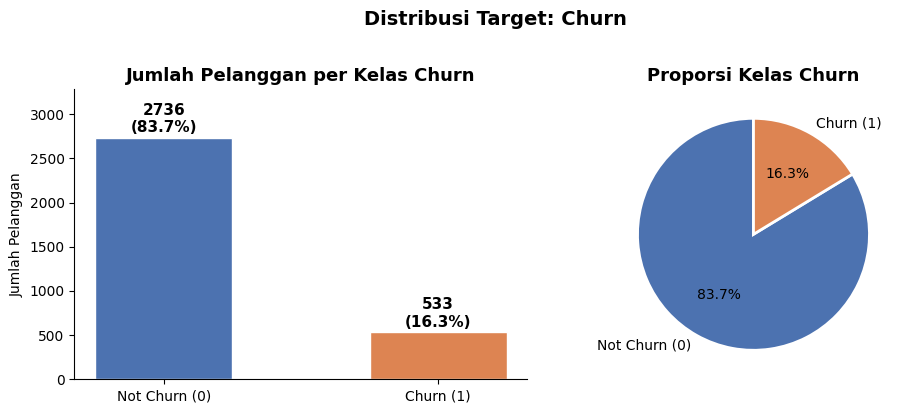

Rasio kelas → Not Churn: 83.7% | Churn: 16.3%
Imbalance ratio (mayoritas:minoritas) ≈ 5.1:1


In [265]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100
labels       = ['Not Churn (0)', 'Churn (1)']
colors       = ['#4C72B0', '#DD8452']

# Bar chart
axes[0].bar(labels, churn_counts.values, color=colors, edgecolor='white', width=0.5)
for i, (v, p) in enumerate(zip(churn_counts.values, churn_pct.values)):
    axes[0].text(i, v + 30, f'{v}\n({p:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Jumlah Pelanggan per Kelas Churn', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Pelanggan')
axes[0].set_ylim(0, churn_counts.max() * 1.2)
axes[0].spines[['top','right']].set_visible(False)

# Pie chart
axes[1].pie(churn_counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporsi Kelas Churn', fontsize=13, fontweight='bold')

plt.suptitle('Distribusi Target: Churn', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Rasio kelas → Not Churn: {churn_pct[0]:.1f}% | Churn: {churn_pct[1]:.1f}%')
print(f'Imbalance ratio (mayoritas:minoritas) ≈ {churn_counts[0]/churn_counts[1]:.1f}:1')

### **4.1.2 Distribusi Fitur Numerik**

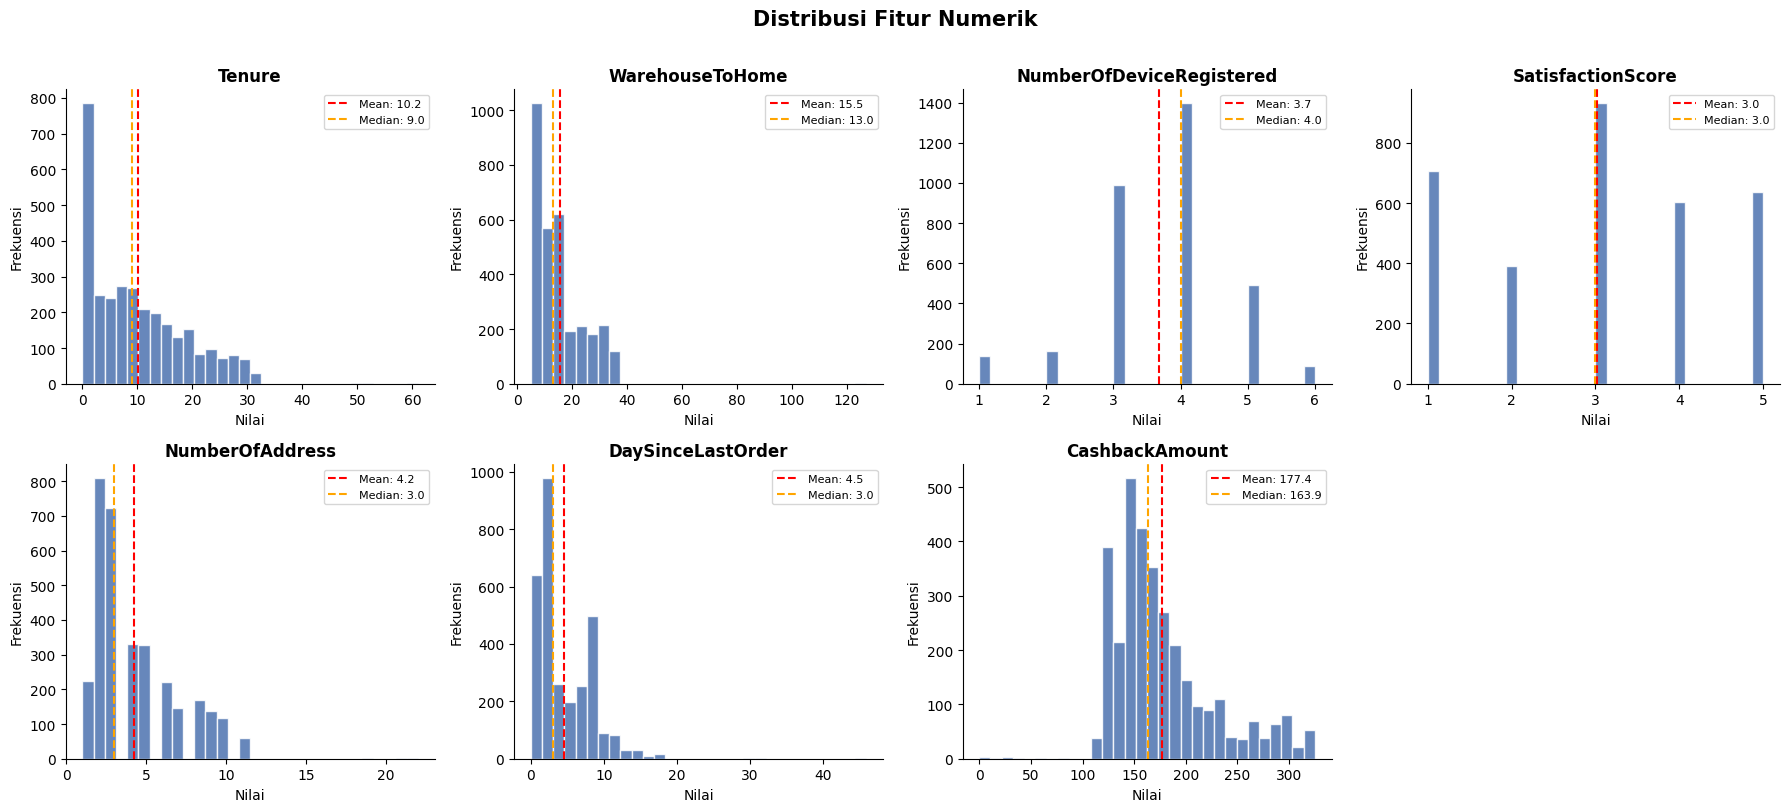

In [266]:
num_cols = ['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered',
            'SatisfactionScore', 'NumberOfAddress', 'DaySinceLastOrder', 'CashbackAmount']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    ax.hist(df[col], bins=30, color='#4C72B0', edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {df[col].median():.1f}')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('Nilai')
    ax.set_ylabel('Frekuensi')
    ax.legend(fontsize=8)
    ax.spines[['top','right']].set_visible(False)

axes[-1].set_visible(False) 
plt.suptitle('Distribusi Fitur Numerik', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [267]:
skew_df = pd.DataFrame({
    'Mean':     df[num_cols].mean().round(2),
    'Median':   df[num_cols].median().round(2),
    'Std':      df[num_cols].std().round(2),
    'Min':      df[num_cols].min().round(2),
    'Max':      df[num_cols].max().round(2),
    'Skewness': df[num_cols].skew().round(3)
})
display(skew_df)

,Mean,Median,Std,Min,Max,Skewness
Tenure,10.19,9.00,8.65,0.0,61.00,0.810
WarehouseToHome,15.51,13.00,8.57,5.0,127.00,1.527
NumberOfDeviceRegistered,3.68,4.00,1.02,1.0,6.00,-0.406
SatisfactionScore,3.02,3.00,1.40,1.0,5.00,-0.086
NumberOfAddress,4.22,3.00,2.62,1.0,22.00,1.115
DaySinceLastOrder,4.55,3.00,3.70,0.0,46.00,1.430
CashbackAmount,177.44,163.89,49.31,0.0,324.99,1.088


### **4.1.3 Distribusi Fitur Kategorikal**


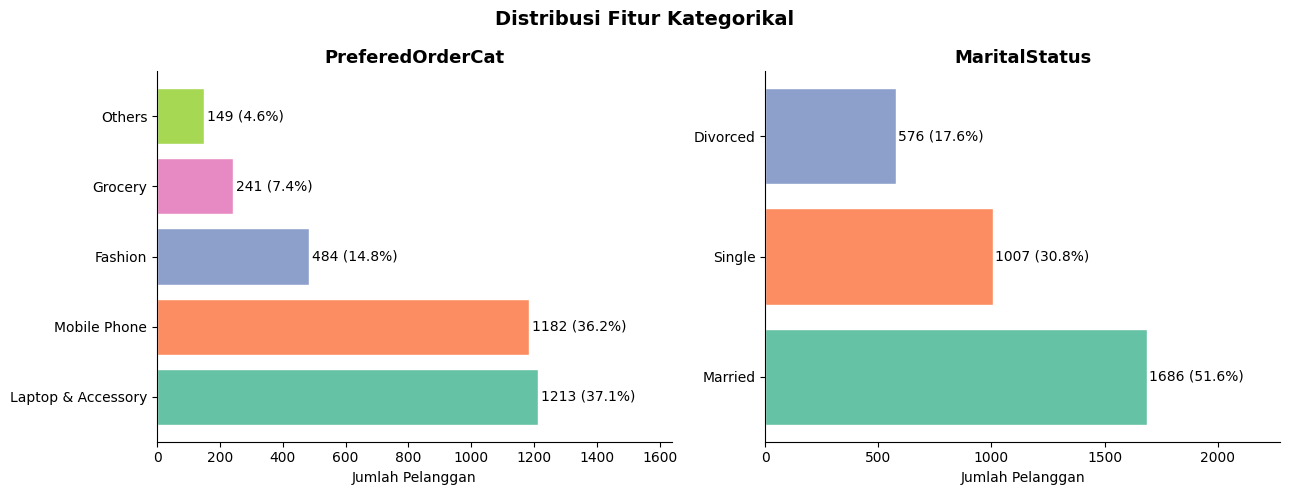

In [268]:
cat_cols = ['PreferedOrderCat', 'MaritalStatus']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col in zip(axes, cat_cols):
    counts = df[col].value_counts()
    pcts   = df[col].value_counts(normalize=True) * 100
    bars   = ax.barh(counts.index, counts.values,
                     color=sns.color_palette('Set2', len(counts)),
                     edgecolor='white')
    for bar, (v, p) in zip(bars, zip(counts.values, pcts.values)):
        ax.text(v + 10, bar.get_y() + bar.get_height()/2,
                f'{v} ({p:.1f}%)', va='center', fontsize=10)
    ax.set_title(col, fontsize=13, fontweight='bold')
    ax.set_xlabel('Jumlah Pelanggan')
    ax.set_xlim(0, counts.max() * 1.35)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Distribusi Fitur Kategorikal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

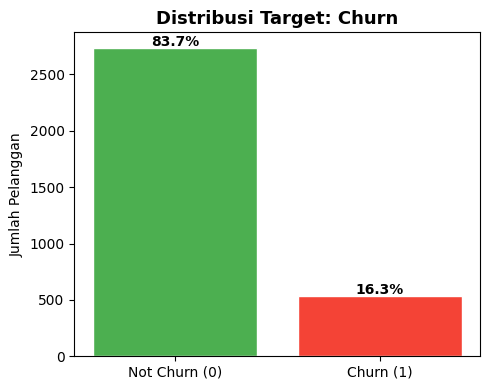

Churn    : 533 (16.3%)
Not Churn: 2,736 (83.7%)


In [269]:
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Not Churn (0)', 'Churn (1)'], churn_counts.values,
              color=['#4CAF50', '#F44336'], edgecolor='white')

for bar, pct in zip(bars, churn_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{pct:.1f}%', ha='center', fontweight='bold')

ax.set_title('Distribusi Target: Churn', fontsize=13, fontweight='bold')
ax.set_ylabel('Jumlah Pelanggan')
plt.tight_layout()
plt.show()

print(f'Churn    : {churn_counts[1]:,} ({churn_pct[1]:.1f}%)')
print(f'Not Churn: {churn_counts[0]:,} ({churn_pct[0]:.1f}%)')

## **4.2 Bivariate Analysis (terhadap Target)**

> 🎯 *Tujuan:* Mencari pola hubungan antara tiap fitur dengan target, untuk menjawab langsung Problem Statement di Section 1.2.

> 📌 Ini bagian paling penting untuk menjawab Problem Statement di Section 1.2 — cari pola antara tiap fitur dengan target, bukan sekadar plot tanpa insight.

### 4.2.1 Numerical Features vs Churn

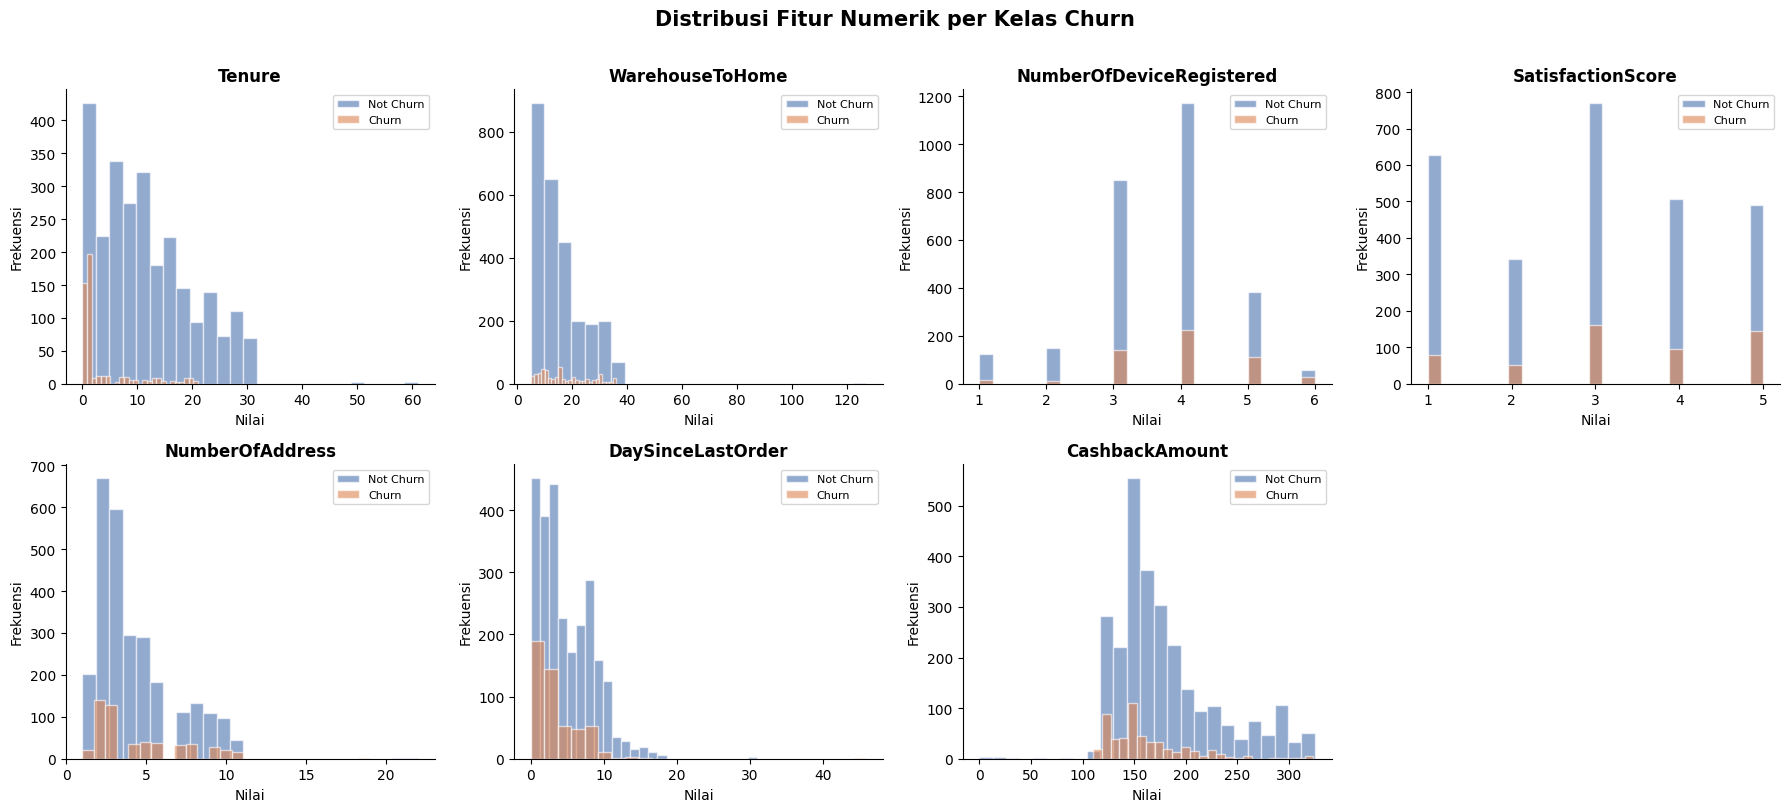

In [270]:
# Distribution of Numeric Features per Churn Class
num_cols = ['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered',
            'SatisfactionScore', 'NumberOfAddress', 'DaySinceLastOrder', 'CashbackAmount']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    for churn_val, label, color in zip([0, 1], ['Not Churn', 'Churn'], ['#4C72B0', '#DD8452']):
        subset = df[df['Churn'] == churn_val][col]
        ax.hist(subset, bins=25, alpha=0.6, label=label, color=color, edgecolor='white')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('Nilai')
    ax.set_ylabel('Frekuensi')
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

axes[-1].set_visible(False)
plt.suptitle('Distribusi Fitur Numerik per Kelas Churn', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

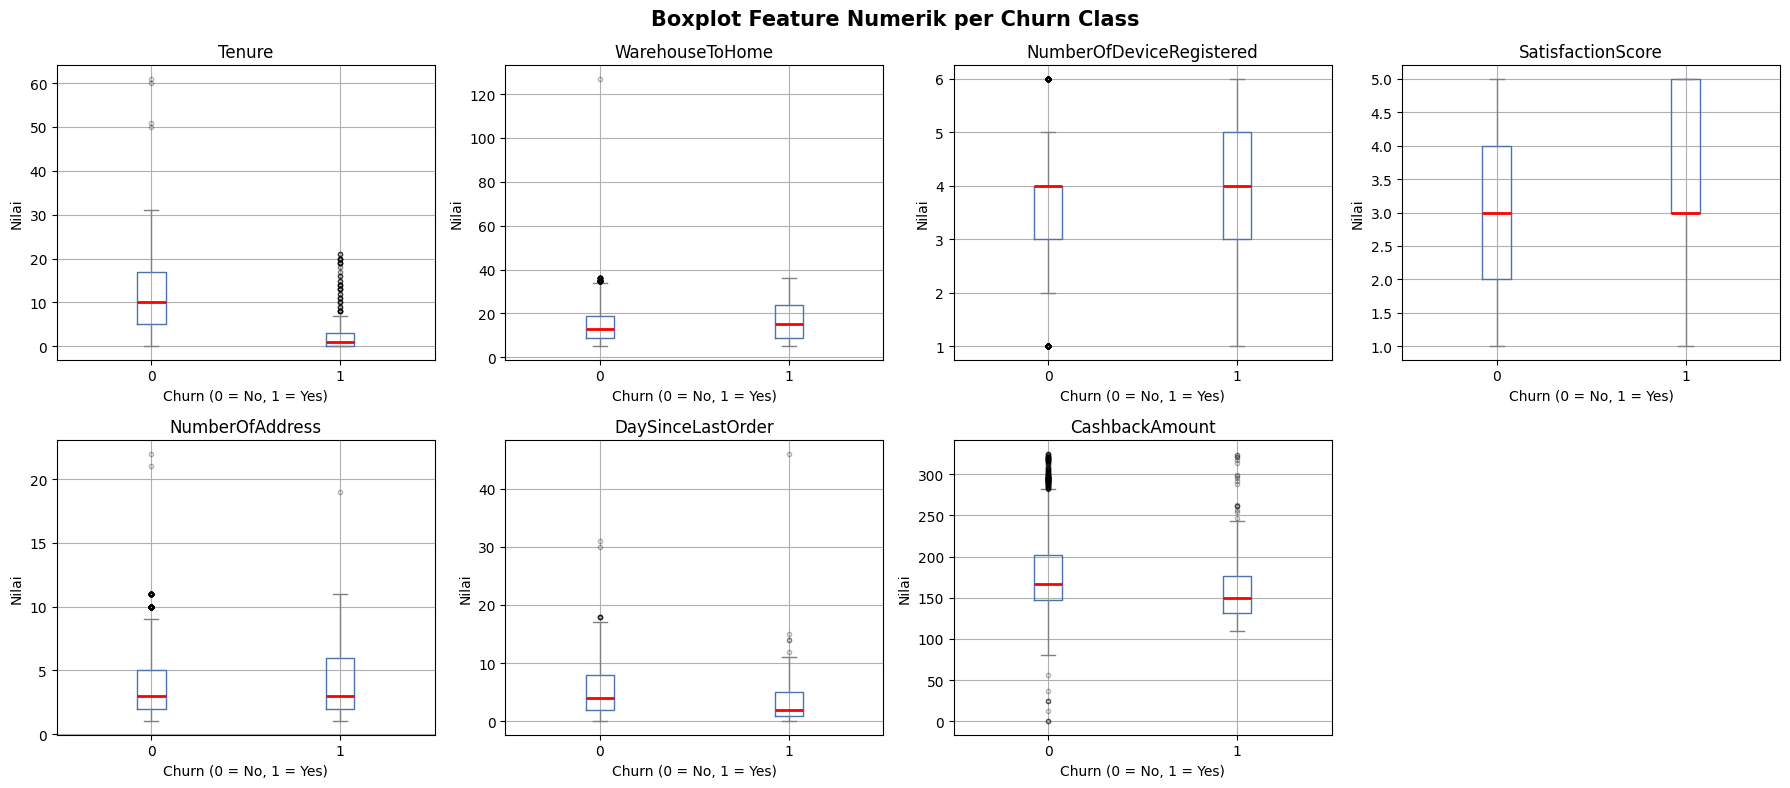

In [271]:
# Boxplot Numeric per Churn Class
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    df.boxplot(column=col, by='Churn', ax=ax,
               boxprops=dict(color='#4C72B0'),
               medianprops=dict(color='red', linewidth=2),
               whiskerprops=dict(color='gray'),
               capprops=dict(color='gray'),
               flierprops=dict(marker='o', color='gray', alpha=0.3, markersize=3))
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('Churn (0 = No, 1 = Yes)')
    ax.set_ylabel('Nilai')
    plt.sca(ax)
    plt.title(col)

axes[-1].set_visible(False)
plt.suptitle('Boxplot Feature Numerik per Churn Class', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.2.2 Categorical Features vs Churn

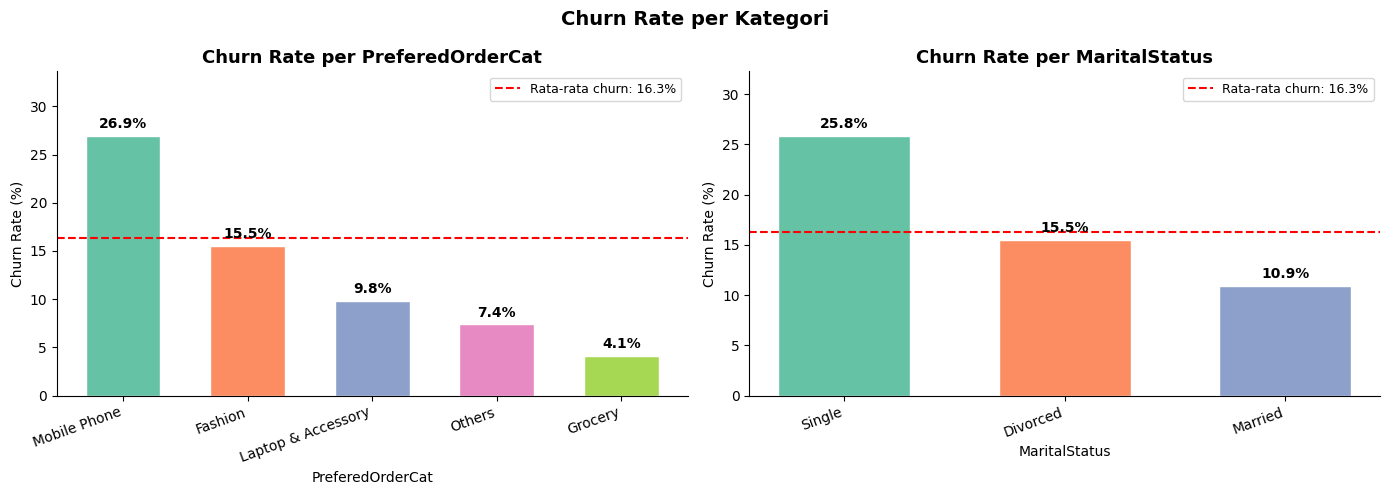

In [272]:
cat_cols = ['PreferedOrderCat', 'MaritalStatus']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, cat_cols):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False) * 100
    bars = ax.bar(churn_rate.index, churn_rate.values,
                  color=sns.color_palette('Set2', len(churn_rate)),
                  edgecolor='white', width=0.6)
    for bar, v in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.5,
                f'{v:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.axhline(df['Churn'].mean() * 100, color='red', linestyle='--',
               linewidth=1.5, label=f'Rata-rata churn: {df["Churn"].mean()*100:.1f}%')
    ax.set_title(f'Churn Rate per {col}', fontsize=13, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Churn Rate (%)')
    ax.set_ylim(0, churn_rate.max() * 1.25)
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right')

plt.suptitle('Churn Rate per Kategori', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

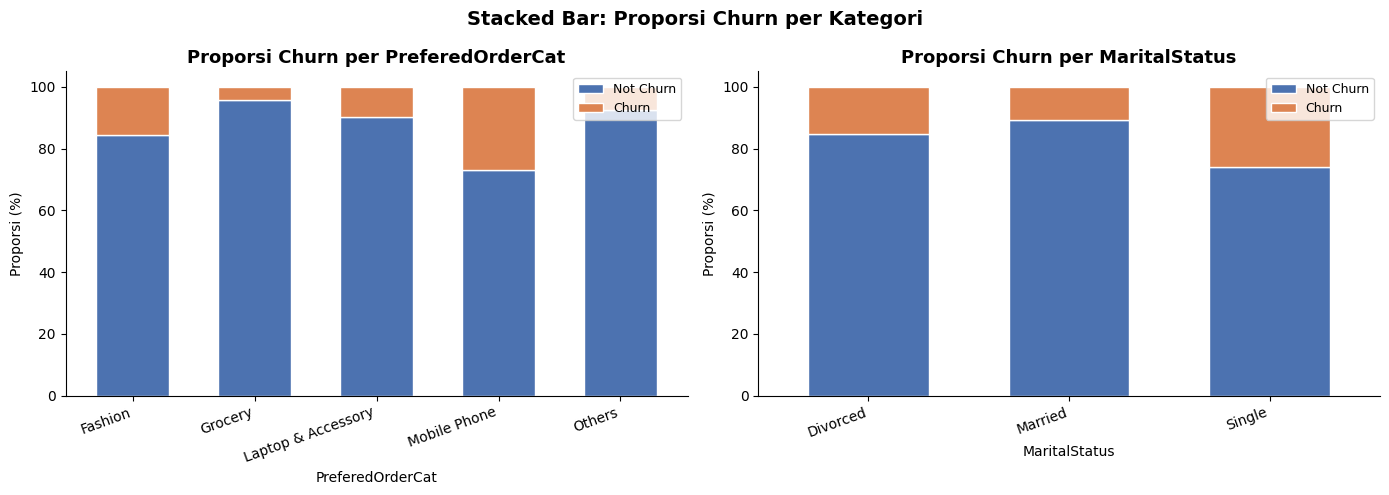

In [273]:
# Stacked Bar Churn per Category
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, cat_cols):
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    ct.columns = ['Not Churn', 'Churn']
    ct.plot(kind='bar', stacked=True, ax=ax,
            color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.6)
    ax.set_title(f'Proporsi Churn per {col}', fontsize=13, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Proporsi (%)')
    ax.legend(loc='upper right', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right')

plt.suptitle('Stacked Bar: Proporsi Churn per Kategori', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## **4.3 Correlation & Multicollinearity Check**

> 🎯 *Tujuan:* Mengecek hubungan antar fitur untuk mendeteksi multikolinearitas yang bisa mengganggu interpretasi model nanti.

### 4.3.1 Correlation Heatmap

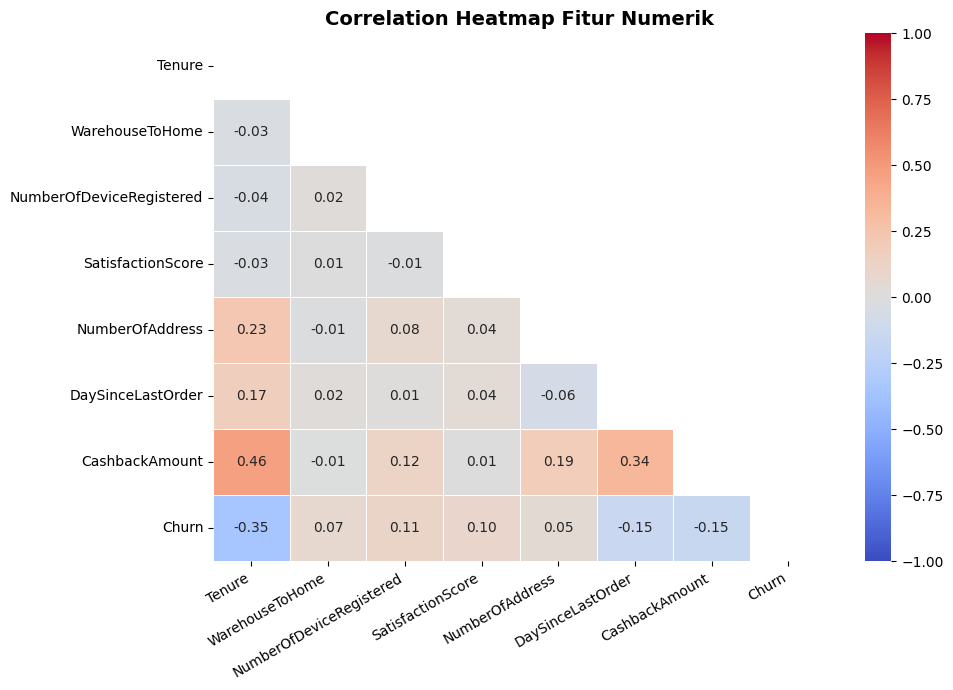

In [274]:
plt.figure(figsize=(10, 7))

corr_matrix = df[num_cols + ['Churn']].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 10})

plt.title('Correlation Heatmap Fitur Numerik', fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

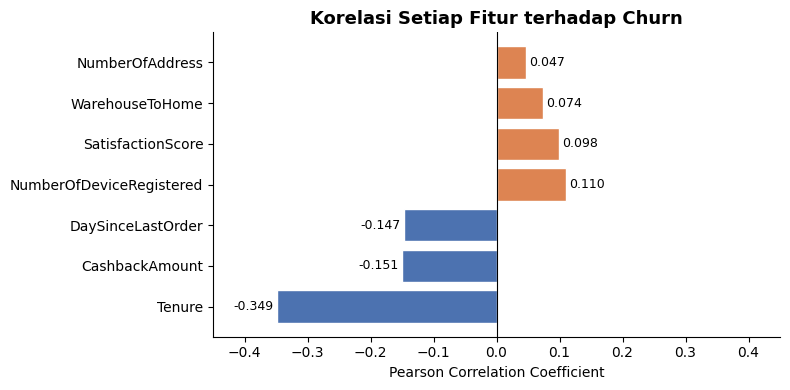

In [275]:
# Sort Highest Correlation Towards Churn
corr_with_churn = corr_matrix['Churn'].drop('Churn').sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 4))
colors = ['#DD8452' if v > 0 else '#4C72B0' for v in corr_with_churn.values]
bars = plt.barh(corr_with_churn.index, corr_with_churn.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
for bar, v in zip(bars, corr_with_churn.values):
    plt.text(v + (0.005 if v >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
             f'{v:.3f}', va='center', ha='left' if v >= 0 else 'right', fontsize=9)
plt.title('Korelasi Setiap Fitur terhadap Churn', fontsize=13, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.xlim(-0.45, 0.45)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### 4.3.2 Pairplot Selected Feature vs Churn

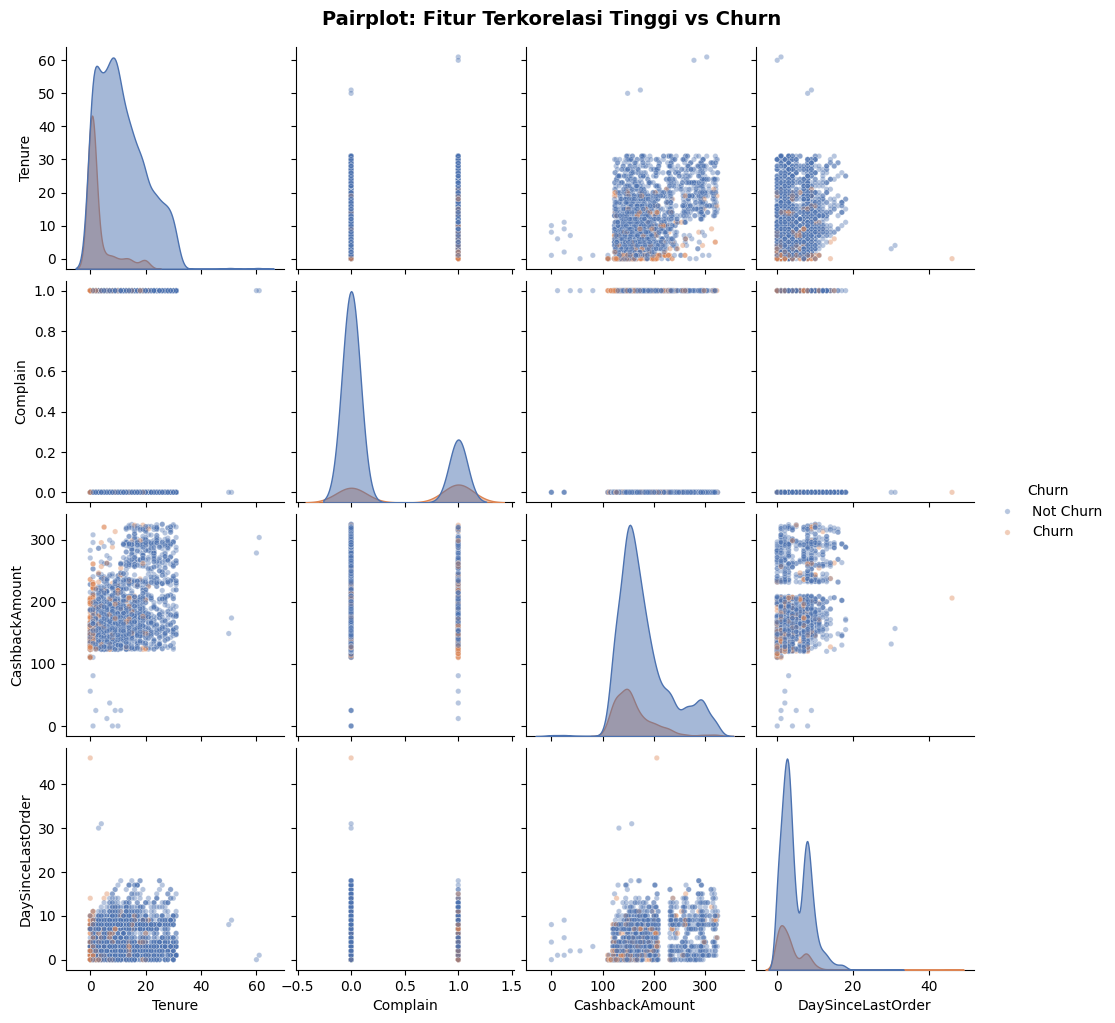

In [276]:
top_features = ['Tenure', 'Complain', 'CashbackAmount', 'DaySinceLastOrder', 'Churn']

pair_df = df[top_features].copy()
pair_df['Churn'] = pair_df['Churn'].map({0: 'Not Churn', 1: 'Churn'})

g = sns.pairplot(pair_df, hue='Churn', palette={'Not Churn': '#4C72B0', 'Churn': '#DD8452'},
                 diag_kind='kde', plot_kws={'alpha': 0.4, 's': 15},
                 diag_kws={'fill': True, 'alpha': 0.5})

g.figure.suptitle('Pairplot: Fitur Terkorelasi Tinggi vs Churn',
                  fontsize=14, fontweight='bold', y=1.02)
plt.show()

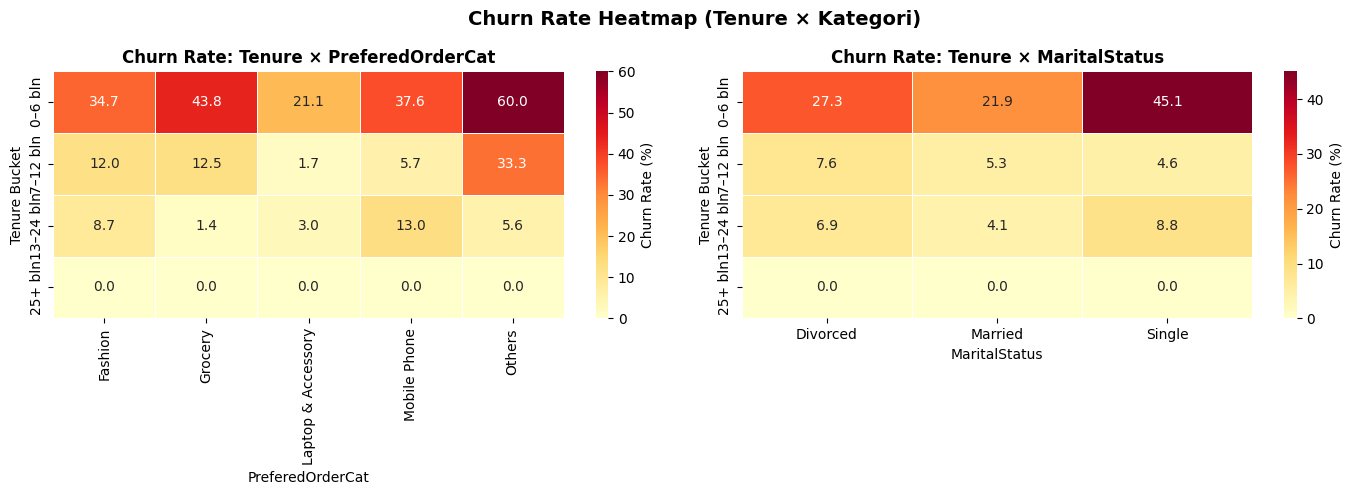

In [277]:
# Create Tenue Bucket
df['Tenure_bucket'] = pd.cut(df['Tenure'], bins=[0, 6, 12, 24, 62],
                              labels=['0–6 bln', '7–12 bln', '13–24 bln', '25+ bln'],
                              include_lowest=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ['PreferedOrderCat', 'MaritalStatus']):
    pivot = df.pivot_table(values='Churn', index='Tenure_bucket',
                           columns=col, aggfunc='mean') * 100
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
                linewidths=0.5, linecolor='white', ax=ax,
                cbar_kws={'label': 'Churn Rate (%)'})
    ax.set_title(f'Churn Rate: Tenure × {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Tenure Bucket')

plt.suptitle('Churn Rate Heatmap (Tenure × Kategori)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Delete Helper Column Once Done
df.drop(columns=['Tenure_bucket'], inplace=True)

## **4.4 Multivariate / Interaction Analysis (opsional)**

> 🎯 *Tujuan:* Menelusuri interaksi antara beberapa fitur sekaligus untuk pola yang lebih kompleks dari yang bisa ditangkap analisis dua arah.

In [278]:
# Skip I guess ¯\_(ツ)_/¯

# **Section 5. Data Preparation**

> 🎯 *Tujuan:* Mengubah data mentah menjadi bentuk siap pakai untuk pemodelan (numerik, terskala, tanpa kategori yang belum di-encode).

## **5.1 Initialization**
- Initialization function
- Define Feature and Target

> 🎯 *Tujuan:* Menyiapkan fungsi bantu dan mendefinisikan mana kolom fitur (X) dan target (y) sebelum transformasi dimulai.

In [279]:
# Define feature & target
feature = df.drop(columns='Churn')
target = df['Churn']

## **5.2 Constructing `Training` and `Testing` Data (from `Seen` Dataset)**

> 🎯 *Tujuan:* Membagi data `Seen` menjadi training dan testing untuk keperluan pengembangan dan evaluasi model.

In [280]:
# TODO: Split dataset into training and testing set
x_train, x_test, y_train, y_test = train_test_split(
    feature,
    target,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=target
)

# Reset index
x_train.reset_index(inplace=True, drop=True)
x_test.reset_index(inplace=True, drop=True)
y_train.reset_index(inplace=True, drop=True)
y_test.reset_index(inplace=True, drop=True)

# Save training and testing datasets
train_df = pd.concat([x_train, y_train], axis=1)
test_df = pd.concat([x_test, y_test], axis=1)

train_df.to_csv('../data/processed/data-train.csv', index=False)
test_df.to_csv('../data/processed/data-test.csv', index=False)

## **5.3 Handling Imbalanced Data (jika relevan)**

> 🎯 *Tujuan:* Menangani ketimpangan proporsi kelas target supaya model tidak bias ke kelas mayoritas.

> 📌 Cek proporsi kelas target di Section 5.1. Kalau timpang (misal 90:10), pertimbangkan strategi seperti class_weight, SMOTE, atau undersampling — **tapi ingat, teknik resampling hanya boleh diterapkan pada data training**, tidak pernah pada data testing/unseen, supaya evaluasi tetap realistis.

In [281]:
# Cek distribusi kelas
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)

Churn
0    2736
1     533
Name: count, dtype: int64
Churn
0    83.69532
1    16.30468
Name: proportion, dtype: float64


## **5.4 Data Transformation (Feature Engineering)**

> 🎯 *Tujuan:* Melakukan encoding, scaling, atau transformasi lain agar data sesuai kebutuhan algoritma yang dipakai.

In [282]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd


class GroupedMedianImputer(BaseEstimator, TransformerMixin):
    """
    Imputasi missing value pada target_col menggunakan median per grup dari group_col.
    Fallback ke median global kalau median grup NaN (grup semua missing) atau
    grupnya gak muncul saat fit (misal grup baru di data test).
    """
    def __init__(self, group_col, target_col):
        self.group_col = group_col
        self.target_col = target_col

    def fit(self, X, y=None):
        df = pd.DataFrame(X, columns=[self.group_col, self.target_col])
        self.group_medians_ = df.groupby(self.group_col)[self.target_col].median()
        self.global_median_ = df[self.target_col].median()
        return self

    def transform(self, X):
        df = pd.DataFrame(X, columns=[self.group_col, self.target_col]).copy()
        mapped_median = df[self.group_col].map(self.group_medians_)
        mapped_median = mapped_median.fillna(self.global_median_)  # jaga-jaga grup baru
        df[self.target_col] = df[self.target_col].fillna(mapped_median)
        return df[[self.target_col]].values
    
    def get_feature_names_out(self, input_features=None):
        return np.array([self.target_col])

# Numerik yang pakai median GLOBAL -> imputasi + scaling
NUMERIC_COLS = [
    "WarehouseToHome",
    "NumberOfDeviceRegistered",
    "NumberOfAddress",
    "DaySinceLastOrder",
    "CashbackAmount",
]

# Numerik yang pakai median PER-KELOMPOK (PreferedOrderCat)
GROUPED_MEDIAN_COL = "Tenure"
GROUP_COL = "PreferedOrderCat"

# Kategorik berbentuk karakter/string -> One-Hot Encoding
CATEGORICAL_CHAR_COLS = [
    "PreferedOrderCat",
    "MaritalStatus",
]

# Kategorik yang sudah berbentuk angka (0/1) -> dibiarkan (tidak di-scale/encode)
CATEGORICAL_NUM_COLS = [
    "SatisfactionScore",
    "Complain",
]

In [ ]:
# Pipeline imputasi SAJA (tanpa scaling/encoding) - harus jalan sebelum Winsorizer
imputation_pipeline = ColumnTransformer(
    transformers=[
        ("numeric_impute", SimpleImputer(strategy="median"), NUMERIC_COLS),
        ("tenure_impute", GroupedMedianImputer(group_col=GROUP_COL, target_col=GROUPED_MEDIAN_COL), [GROUP_COL, GROUPED_MEDIAN_COL]),
        ("cat_char_impute", SimpleImputer(strategy="most_frequent"), CATEGORICAL_CHAR_COLS),
        ("cat_num_impute", SimpleImputer(strategy="most_frequent"), CATEGORICAL_NUM_COLS),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
).set_output(transform="pandas")

# Preprocessing SETELAH imputasi: scaling + encoding
preprocessor = ColumnTransformer(
    transformers=[
        ("scale_numeric", RobustScaler(), NUMERIC_COLS + [GROUPED_MEDIAN_COL]),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_CHAR_COLS),
    ],
    remainder="passthrough"  
)

# Base model pipeline with resampling
model_res_pipeline = ImbPipeline(steps=[
    ('imputation', imputation_pipeline),
    ('outlier_capping', Winsorizer(variables=NUMERIC_COLS + [GROUPED_MEDIAN_COL])),
    ('feature_engineering', preprocessor),
    ('feature_selection', SelectKBest(random_state=RANDOM_STATE)),
    ('feature_resampling', SMOTE(random_state=RANDOM_STATE)),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE))
])
model_res_pipeline.fit(x_train, y_train)

,steps,"[('imputation', ...), ('outlier_capping', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric_impute', ...), ('tenure_impute', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be 

## **5.5 Feature Selection**

> 🎯 *Tujuan:* Memilih fitur yang paling relevan/berkontribusi untuk mengurangi noise dan risiko overfitting.

In [284]:
# pastikan pipeline sudah di-fit dulu
# model_res_pipeline.fit(X_train, y_train)

# 1. Ambil step yang relevan dari pipeline
preprocessor_fitted = model_res_pipeline.named_steps['feature_engineering']
selector_fitted = model_res_pipeline.named_steps['feature_selection']

# 2. Ambil nama fitur hasil ColumnTransformer (urutan sesuai urutan transformer di dalamnya)
feature_names_after_preprocessing = preprocessor_fitted.get_feature_names_out()

# 3. Ambil mask boolean fitur yang terpilih dari SelectKBest
selected_mask = selector_fitted.get_support()

# 4. Gabungkan -> nama fitur yang lolos seleksi
selected_features = feature_names_after_preprocessing[selected_mask]

print(f"Jumlah fitur sebelum seleksi : {len(feature_names_after_preprocessing)}")
print(f"Jumlah fitur setelah seleksi : {len(selected_features)}")
print(selected_features)

Jumlah fitur sebelum seleksi : 16
Jumlah fitur setelah seleksi : 10
['scale_numeric__NumberOfDeviceRegistered'
 'scale_numeric__DaySinceLastOrder' 'scale_numeric__CashbackAmount'
 'scale_numeric__Tenure' 'onehot__PreferedOrderCat_Laptop & Accessory'
 'onehot__PreferedOrderCat_Mobile Phone' 'onehot__MaritalStatus_Married'
 'onehot__MaritalStatus_Single' 'remainder__SatisfactionScore'
 'remainder__Complain']


## **5.6 Overview**

> 🎯 *Tujuan:* Merangkum hasil akhir data preparation (bentuk data final) sebelum masuk ke tahap Model Development.

Tahapan data preparation yang telah dilakukan meliputi:

1. **Outlier Capping (Winsorizer)** — dilakukan pada kolom numerik (`NUMERIC_COLS`) untuk membatasi pengaruh nilai ekstrem tanpa menghapus baris data, guna menjaga ukuran sampel tetap utuh.
2. **Feature Engineering (ColumnTransformer)**:
   - Kolom numerik diimputasi (median) dan di-scaling menggunakan `RobustScaler` agar tahan terhadap outlier residual.
   - Kolom kategorikal string (`CATEGORICAL_CHAR_COLS`) diimputasi (`constant: unknown`) dan di-encode menggunakan One-Hot Encoding.
   - Kolom kategorikal biner (`CATEGORICAL_NUM_COLS`) diimputasi (`most_frequent`) tanpa transformasi lebih lanjut.
3. **Feature Selection (SelectKBest)** — dilakukan seleksi fitur untuk mengurangi dimensi dan menghilangkan fitur yang kurang informatif terhadap target (`Churn`).
4. **Resampling (SMOTE)** — diterapkan pada pipeline `model_res_pipeline` untuk menangani ketidakseimbangan kelas pada target, dengan sintesis data pada kelas minoritas.

**Ringkasan bentuk data akhir:**

| Tahap                          | Jumlah Baris | Jumlah Fitur |
|---------------------------------|--------------|--------------|
| Sebelum preprocessing            | `<isi>`      | `<isi>`      |
| Setelah encoding (sebelum seleksi)| `<isi>`     | `<isi>`      |
| Setelah feature selection        | `<isi>`      | `<isi>`      |
| Setelah resampling (train saja)  | `<isi>`      | `<isi>`      |

Distribusi target sebelum dan sesudah resampling:

| Kelas   | Sebelum SMOTE | Sesudah SMOTE |
|---------|---------------|----------------|
| 0 (No)  | `<isi>`       | `<isi>`        |
| 1 (Yes) | `<isi>`       | `<isi>`        |

Dengan tahapan ini, data telah siap digunakan untuk proses pelatihan model pada tahap **Model Development**.

# **Section 6. Model Development**

> 🎯 *Tujuan:* Membangun, membandingkan, dan menyempurnakan model machine learning menggunakan data.

## **6.1 Initialization**
- Initialization Function
- Create Custom Metrics
- Define Cross-Validation Strategy
- Create a workflow of the experiment

> 🎯 *Tujuan:* Menyiapkan fungsi metrik custom dan strategi cross-validation yang dipakai konsisten di seluruh eksperimen model.

> 📌 Tentukan strategi CV secara eksplisit (misal `StratifiedKFold` untuk klasifikasi dengan target tidak seimbang) dan simpan `RANDOM_STATE` yang sama dari Section 0. Ingat prinsip **CV-first**: bandingkan model lewat cross-validation dulu, baru evaluasi akhir di data testing — jangan sebaliknya.

In [285]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (make_scorer, recall_score, precision_score,
                             f1_score, roc_auc_score, fbeta_score,
                             ConfusionMatrixDisplay)
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay

# CV Strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Custom F2 scorer
f2_scorer = make_scorer(fbeta_score, beta=2, pos_label=1)

# Scorer dict — ROC-AUC dihitung manual terpisah karena ImbPipeline
# tidak kompatibel dengan needs_proba scorer di cross_validate
scorers = {
    'recall':    make_scorer(recall_score,    pos_label=1),
    'precision': make_scorer(precision_score, pos_label=1, zero_division=0),
    'f1':        make_scorer(f1_score,        pos_label=1),
    'f2':        f2_scorer,
}

# Helper: hitung ROC-AUC manual per fold
def compute_roc_auc_cv(pipeline, X, y, cv):
    roc_scores = []
    for train_idx, val_idx in cv.split(X, y):
        X_tr  = X.iloc[train_idx]
        X_val = X.iloc[val_idx]
        y_tr  = y.iloc[train_idx]
        y_val = y.iloc[val_idx]
        pipeline.fit(X_tr, y_tr)
        proba = pipeline.predict_proba(X_val)[:, 1]
        roc_scores.append(roc_auc_score(y_val, proba))
    return np.array(roc_scores)

# Helper: print CV result summary
def print_cv_results(name, cv_results, roc_scores=None):
    metrics = ['recall', 'precision', 'f1', 'f2']
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    for m in metrics:
        scores = cv_results[f'test_{m}']
        print(f"  {m:<12}: {scores.mean():.4f} ± {scores.std():.4f}")
    if roc_scores is not None:
        print(f"  {'roc_auc':<12}: {roc_scores.mean():.4f} ± {roc_scores.std():.4f}")

## **6.2 Developing the Model Pipeline**

> 🎯 *Tujuan:* Merangkai seluruh langkah preprocessing dan model ke dalam satu objek Pipeline yang konsisten dipakai ulang.

> 📌 Gunakan `Pipeline`/`ColumnTransformer` dari scikit-learn supaya seluruh langkah preprocessing (imputasi, encoding, scaling) ikut ter-*fit* hanya pada data training di setiap fold — ini mencegah data leakage antara fold CV.

In [286]:
# TODO: Inisialisasi model
logreg = LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced')
dt = DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced')
knn = KNeighborsClassifier()
rf = RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced')
xgb = XGBClassifier(
    random_state=RANDOM_STATE,
    scale_pos_weight=2736/534,  # ≈ 5.1
    eval_metric='logloss',
    verbosity=0
)
ab = AdaBoostClassifier(random_state=RANDOM_STATE)
gb = GradientBoostingClassifier(random_state=RANDOM_STATE)

In [ ]:
# Kandidat model
candidates = {
    'Logistic Regression': logreg,
    'KNN':                 knn,
    'Decision Tree':       dt,
    'Random Forest':       rf,
    'XGBoost':             xgb,
    'AdaBoost' :           ab,
    'GradientBoost' :      gb
}

## **6.3 Model Benchmarking (Comparing model base performance)**

> 🎯 *Tujuan:* Membandingkan performa dasar beberapa algoritma (tanpa tuning) untuk memilih kandidat terbaik yang layak dituning lebih lanjut.

### 6.3.1 Model Benchmarking with Resampling

In [ ]:
def benchmark_models(pipeline, candidates, x_train, y_train, 
                      scoring="recall", cv=5, random_state=RANDOM_STATE):
    """
    Benchmark beberapa model classifier menggunakan cross-validation
    di atas satu pipeline yang sama (hanya step 'classifier' yang diganti).

    Parameters
    ----------
    pipeline : sklearn Pipeline
        Pipeline yang punya step bernama 'classifier' (mis. model_res_pipeline).
    candidates : dict
        {"nama_model": estimator, ...}
    x_train, y_train : array-like
        Data training.
    scoring : str
        Metric untuk cross_validate.
    cv : int
        Jumlah fold untuk StratifiedKFold (default 5).
    random_state : int or None
        Untuk shuffle di StratifiedKFold, jika ingin reproducible.

    Returns
    -------
    pd.DataFrame
        Ringkasan mean & std train/test score per model, diurutkan
        berdasarkan mean_test_score tertinggi.
    """
    all_cv_result = []

    skf = StratifiedKFold(
        n_splits=cv,
        shuffle=True,
        random_state=random_state
    )

    for name, model in candidates.items():
        classifier = pipeline.set_params(classifier=model)
        cv_result = cross_validate(
            estimator=classifier,
            X=x_train, y=y_train,
            cv=skf,
            scoring=scoring,
            return_train_score=True
        )
        all_cv_result.append({
            "name": name,
            "mean_train_score": np.mean(cv_result["train_score"]),
            "std_train_score": np.std(cv_result["train_score"]),
            "mean_test_score": np.mean(cv_result["test_score"]),
            "std_test_score": np.std(cv_result["test_score"])
        })

    result_df = pd.DataFrame(all_cv_result).sort_values(
        "mean_test_score", ascending=False
    ).reset_index(drop=True)

    return result_df

In [ ]:
# With resampling
benchmark_models(
    model_res_pipeline, 
    candidates, 
    x_train, 
    y_train, 
    scoring="recall",
    cv=5, 
    random_state=RANDOM_STATE
)

,name,mean_train_score,std_train_score,mean_test_score,std_test_score
0,Logistic Regression,0.814563,0.017937,0.800492,0.045142
1,AdaBoost,0.798132,0.015332,0.765390,0.059330
2,XGBoost,1.000000,0.000000,0.706539,0.062833
3,KNN,0.964794,0.011116,0.706512,0.076085
4,GradientBoost,0.766436,0.010332,0.692640,0.084279
5,Random Forest,1.000000,0.000000,0.624460,0.050614
6,Decision Tree,1.000000,0.000000,0.610233,0.039767


### 6.3.2 Model Ensemble Benchmarking
#### 6.3.2.1 Various Type

In [290]:
# TODO: Model initialization
voting = VotingClassifier(estimators=[('knn', knn), ('dt', dt), ('logreg', logreg)], voting='soft')
stacking = StackingClassifier(
    estimators=[('knn', knn), ('dt', dt)],
    final_estimator=logreg
)

In [291]:
# TODO: Benchmark process
benchmark_various = benchmark_models(
    pipeline=model_res_pipeline, 
    candidates={'voting' : voting, 'stacking' : stacking}, 
    x_train=x_train, 
    y_train=y_train, 
    cv=5,
    random_state=RANDOM_STATE
)

In [292]:
benchmark_various

,name,mean_train_score,std_train_score,mean_test_score,std_test_score
0,voting,0.992955,0.003001,0.711354,0.059309
1,stacking,0.988841,0.008805,0.589330,0.063031


#### 6.3.2.2 Similar Type

In [293]:
# Model initialization
similar_model = {
    'Random Forest':       rf,
    'XGBoost':             xgb,
    'AdaBoost' :           ab,
    'GradientBoost' :      gb
}

In [294]:
# TODO: Benchmark process
benchmark_similar = benchmark_models(
    pipeline=model_res_pipeline,
    candidates=similar_model,
    x_train=x_train,
    y_train=y_train,
    cv=5,
    random_state=RANDOM_STATE
)

In [295]:
benchmark_similar

,name,mean_train_score,std_train_score,mean_test_score,std_test_score
0,AdaBoost,0.777599,0.023933,0.744350,0.069237
1,XGBoost,1.000000,0.000000,0.725390,0.059604
2,GradientBoost,0.758805,0.012598,0.678550,0.079622
3,Random Forest,1.000000,0.000000,0.624323,0.055709


## **6.4 Tune Model**

> 🎯 *Tujuan:* Mengoptimalkan hyperparameter dari model kandidat terbaik hasil benchmarking untuk meningkatkan performa.

### 6.4.1 Logistic Regression Tuning

In [296]:
# TODO: Save best logreg
best_logreg = clone(model_res_pipeline.set_params(classifier=logreg))

In [297]:
lr_param_grid = {
    'classifier__C':            [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier__penalty':      ['l1', 'l2'],
    'classifier__solver':       ['liblinear', 'saga'],
    'classifier__class_weight': [None, 'balanced'],
    'feature_selection__k':     [8, 10, 12, 'all'],
}

lr_tuning = RandomizedSearchCV(
    estimator=best_logreg,
    param_distributions=lr_param_grid,
    n_iter=50,
    scoring='recall',
    cv=StratifiedKFold(),
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)
lr_tuning.fit(x_train, y_train)

print(f"\nBest Recall LR : {lr_tuning.best_score_:.4f}")
print(f"Best params     : {lr_tuning.best_params_}")
best_lr = lr_tuning.best_estimator_

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Recall LR : 0.8543
Best params     : {'feature_selection__k': 8, 'classifier__solver': 'liblinear', 'classifier__penalty': 'l1', 'classifier__class_weight': None, 'classifier__C': 0.01}


#### Evaluation Before VS After Tuning

In [298]:
# Model before tuning
base_logreg = clone(model_res_pipeline.set_params(classifier=logreg))
base_logreg.fit(x_train, y_train)

# Model after tuning
tunned_logreg = lr_tuning.best_estimator_
tunned_logreg.fit(x_train, y_train)

,steps,"[('imputation', ...), ('outlier_capping', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric_impute', ...), ('tenure_impute', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be 

In [299]:
# TODO: Model prediction (before tuning)
y_train_pred = base_logreg.predict(x_train)
y_test_pred = base_logreg.predict(x_test)

print('Base model Logistic Regression')
print(f'Model performance (train): {recall_score(y_train, y_train_pred):.2%}')
print(f'Model performance (test): {recall_score(y_test, y_test_pred):.2%}')

Base model Logistic Regression
Model performance (train): 81.92%
Model performance (test): 79.44%


In [300]:
# TODO: Model prediction (after tuning)
y_train_pred = tunned_logreg.predict(x_train)
y_test_pred = tunned_logreg.predict(x_test)

print('Base model Logistic Regression')
print(f'Model performance (train): {recall_score(y_train, y_train_pred):.2%}')
print(f'Model performance (test): {recall_score(y_test, y_test_pred):.2%}')

Base model Logistic Regression
Model performance (train): 84.98%
Model performance (test): 85.05%


### 6.4.2 AdaBoost  Tuning

In [301]:
# TODO: Save best AdaBoost
best_ab = clone(model_res_pipeline.set_params(classifier=ab))

In [302]:
ab_param_grid = {
    'classifier__n_estimators':  [50, 100, 200, 300],
    'classifier__learning_rate': [0.01, 0.1, 0.5, 1.0],
    'feature_selection__k':      [8, 10, 12, 'all'],
}

ab_tuning = RandomizedSearchCV(
    estimator=model_res_pipeline.set_params(
        classifier=AdaBoostClassifier(random_state=RANDOM_STATE)
    ),
    param_distributions=ab_param_grid,
    n_iter=50,
    scoring='recall',
    cv=StratifiedKFold(),
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)
ab_tuning.fit(x_train, y_train)

print(f"\nBest Recall AB : {ab_tuning.best_score_:.4f}")
print(f"Best params    : {ab_tuning.best_params_}")
best_ab = ab_tuning.best_estimator_

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Recall AB : 0.8005
Best params    : {'feature_selection__k': 8, 'classifier__n_estimators': 300, 'classifier__learning_rate': 0.5}


In [303]:
# Model before tuning
base_ab = clone(model_res_pipeline.set_params(classifier=ab))
base_ab.fit(x_train, y_train)

# Model after tuning
tunned_ab = ab_tuning.best_estimator_
tunned_ab.fit(x_train, y_train)

,steps,"[('imputation', ...), ('outlier_capping', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric_impute', ...), ('tenure_impute', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be 

In [304]:
# TODO: Model prediction (before tuning)
y_train_pred = base_ab.predict(x_train)
y_test_pred = base_ab.predict(x_test)

print('Base model AdaBoost')
print(f'Model performance (train): {recall_score(y_train, y_train_pred):.2%}')
print(f'Model performance (test): {recall_score(y_test, y_test_pred):.2%}')

Base model AdaBoost
Model performance (train): 78.87%
Model performance (test): 79.44%


In [305]:
# TODO: Model prediction (after tuning)
y_train_pred = tunned_ab.predict(x_train)
y_test_pred = tunned_ab.predict(x_test)

print('Base model AdaBoost (After Tuning)')
print(f'Model performance (train): {recall_score(y_train, y_train_pred):.2%}')
print(f'Model performance (test): {recall_score(y_test, y_test_pred):.2%}')

Base model AdaBoost (After Tuning)
Model performance (train): 81.92%
Model performance (test): 83.18%


### 6.4.3 GradientBoost Tuning

In [306]:
# TODO: Save best AdaBoost
best_gb = clone(model_res_pipeline.set_params(classifier=gb))

In [307]:
gb_param_grid = {
    'classifier__n_estimators':  [50, 100, 200, 300],
    'classifier__learning_rate': [0.01, 0.1, 0.5, 1.0],
    'classifier__max_depth':     [3, 4, 5],
    'classifier__subsample':     [0.7, 0.8, 1.0],
    'feature_selection__k':      [8, 10, 12, 'all'],
}

gb_tuning = RandomizedSearchCV(
    estimator=model_res_pipeline.set_params(
        classifier=GradientBoostingClassifier(random_state=RANDOM_STATE)  # ← fix: bukan AdaBoost
    ),
    param_distributions=gb_param_grid,
    n_iter=50,
    scoring='recall',
    cv=StratifiedKFold(),
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)
gb_tuning.fit(x_train, y_train)

print(f"\nBest Recall GB : {gb_tuning.best_score_:.4f}")
print(f"Best params    : {gb_tuning.best_params_}")
best_gb = gb_tuning.best_estimator_  # ← fix: bukan ab_tuning

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Recall GB : 0.7724
Best params    : {'feature_selection__k': 8, 'classifier__subsample': 0.8, 'classifier__n_estimators': 300, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.01}


In [308]:
# Model before tuning
base_gb = clone(model_res_pipeline.set_params(classifier=gb))
base_gb.fit(x_train, y_train)

# Model after tuning
tunned_gb = gb_tuning.best_estimator_
tunned_gb.fit(x_train, y_train)

,steps,"[('imputation', ...), ('outlier_capping', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric_impute', ...), ('tenure_impute', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be 

In [309]:
# TODO: Model prediction (before tuning)
y_train_pred = base_gb.predict(x_train)
y_test_pred = base_gb.predict(x_test)

print('Base model GradientBoost')
print(f'Model performance (train): {recall_score(y_train, y_train_pred):.2%}')
print(f'Model performance (test): {recall_score(y_test, y_test_pred):.2%}')

Base model GradientBoost
Model performance (train): 76.06%
Model performance (test): 69.16%


In [310]:
# TODO: Model prediction (after tuning)
y_train_pred = tunned_gb.predict(x_train)
y_test_pred = tunned_gb.predict(x_test)

print('Base model GradientBoost (After Tuning)')
print(f'Model performance (train): {recall_score(y_train, y_train_pred):.2%}')
print(f'Model performance (test): {recall_score(y_test, y_test_pred):.2%}')

Base model GradientBoost (After Tuning)
Model performance (train): 81.69%
Model performance (test): 78.50%


### 6.4.4 Comparing Tuning Results

In [311]:
tuning_rows = []

for name, tuning, best_model in [
    ('Logistic Regression (tuned)', lr_tuning,  best_lr),
    ('AdaBoost (tuned)',            ab_tuning,  best_ab),
    ('GradientBoost (tuned)',       gb_tuning,  best_gb),
]:
    y_pred = best_model.predict(x_test)
    roc    = roc_auc_score(y_test, best_model.predict_proba(x_test)[:, 1])
    tuning_rows.append({
        'Model':            name,
        'Best CV Recall':   round(tuning.best_score_, 4),
        'Test Recall':      round(recall_score(y_test, y_pred), 4),
        'Test Precision':   round(precision_score(y_test, y_pred), 4),
        'Test F2':          round(fbeta_score(y_test, y_pred, beta=2), 4),
        'Test ROC-AUC':     round(roc, 4),
    })

tuning_df = pd.DataFrame(tuning_rows).sort_values('Test Recall', ascending=False)
display(tuning_df)

,Model,Best CV Recall,Test Recall,Test Precision,Test F2,Test ROC-AUC
0,Logistic Regression (tuned),0.8543,0.8505,0.3597,0.6681,0.8646
1,AdaBoost (tuned),0.8005,0.8318,0.5057,0.7368,0.8916
2,GradientBoost (tuned),0.7724,0.7850,0.5185,0.7119,0.8993


### 6.4.4 Choosing the best results

In [ ]:
best_model = best_lr
print(f"Best model  : {best_model.named_steps['classifier'].__class__.__name__}")
print(f"Test Recall : {recall_score(y_test, best_model.predict(x_test)):.4f}")
print(f"Test F2     : {fbeta_score(y_test, best_model.predict(x_test), beta=2):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, best_model.predict_proba(x_test)[:,1]):.4f}")

Best model  : LogisticRegression
Test Recall : 0.8505
Test F2     : 0.6681
Test ROC-AUC: 0.8646


## **6.5 Analyze Model**
- Evaluate model on data testing
- Confusion Matrix / Threshold Analysis (Classification) atau Residual Analysis (Regression)
- Learning Curve Inspection

> 🎯 *Tujuan:* Mengevaluasi performa model secara mendalam di luar satu angka metrik utama, termasuk mengecek tanda overfitting/underfitting.

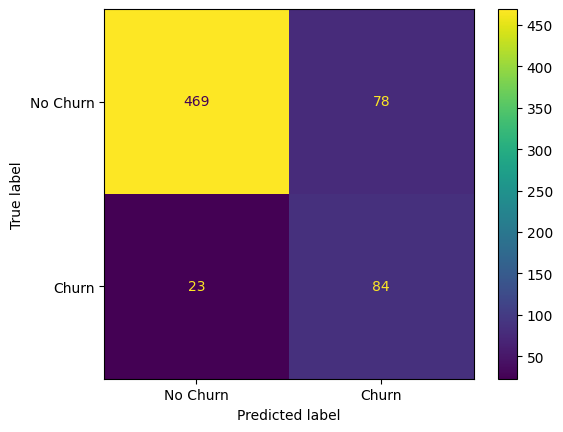

In [323]:
# TODO: Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, display_labels=['No Churn', 'Churn'])
plt.show()

In [324]:
# TODO: Classification report
print('Classification Report (Train)')
print(classification_report(y_train, y_train_pred, target_names=['Tidak Churn', 'Churn']))

print('\nClassification Report (Test)')
print(classification_report(y_test, y_test_pred, target_names=['Tidak Churn', 'Churn']))

Classification Report (Train)
              precision    recall  f1-score   support

 Tidak Churn       0.96      0.83      0.89      2189
       Churn       0.49      0.82      0.61       426

    accuracy                           0.83      2615
   macro avg       0.72      0.82      0.75      2615
weighted avg       0.88      0.83      0.85      2615


Classification Report (Test)
              precision    recall  f1-score   support

 Tidak Churn       0.95      0.86      0.90       547
       Churn       0.52      0.79      0.62       107

    accuracy                           0.85       654
   macro avg       0.74      0.82      0.76       654
weighted avg       0.88      0.85      0.86       654



## **6.6 Model Calibration (Classification Only)**

> 🎯 *Tujuan:* Menyesuaikan output probabilitas model supaya lebih merepresentasikan kemungkinan sebenarnya, penting saat threshold dipakai untuk keputusan bisnis.

## **6.7 Model Explanation and Interpretation**
- Feature Importance (Tree Based Model) / Coefficient Regression (Regression Based Model)
- SHAP Value identification
- Counterfactual Analysis

> 🎯 *Tujuan:* Menjelaskan bagaimana model mengambil keputusan — penting untuk membangun kepercayaan stakeholder bisnis terhadap model.

# **Section 7. Model Deployment**

> 🎯 *Tujuan:* Menyiapkan model terlatih agar bisa dipakai di luar notebook, lengkap dengan dokumentasi teknis yang diperlukan.

## **7.1 Export Model (joblib/pickle)**

> 🎯 *Tujuan:* Menyimpan pipeline terlatih ke dalam file yang bisa dimuat ulang tanpa perlu melatih ulang dari awal.

> 📌 Minimal, export pipeline lengkap (bukan cuma model) dengan `joblib.dump()` supaya preprocessing dan model tetap satu paket saat dipakai ulang.

## **7.2 Deployment Checklist**
- Versi library yang digunakan
- Format input yang diharapkan model
- Cara memuat ulang pipeline

> 🎯 *Tujuan:* Mendokumentasikan hal teknis yang perlu diperhatikan tim lain saat model dipakai di lingkungan produksi.

# **Section 8. Model Implementation**

> 🎯 *Tujuan:* Menjelaskan cara pakai model di dunia nyata, batasannya, dan dampak bisnisnya lewat simulasi.

## **8.1 How to implement the model?**

> 🎯 *Tujuan:* Menjelaskan langkah teknis memakai model untuk melakukan prediksi pada data baru.

## **8.2 What are the limitations of the model?**

> 🎯 *Tujuan:* Mengakui batasan model secara jujur, termasuk skenario di mana prediksinya kurang bisa diandalkan.

## **8.3 Business Calculation (Simulation using unseen data)**

> 🎯 *Tujuan:* Mensimulasikan dampak bisnis dari penggunaan model, memakai data `unseen` yang belum pernah dilihat selama proses modeling.

> 📌 Ini saatnya `unseen` data dipakai. Kaitkan hasil simulasi dengan metrik bisnis yang kamu tetapkan di Section 1.5 — misalnya, hitung estimasi kerugian akibat False Negative vs biaya operasional akibat False Positive, sesuai threshold yang dipilih.

# **Section 9. Conclusion and Recommendation**

> 🎯 *Tujuan:* Merangkum keseluruhan proyek dan menerjemahkan hasil teknis kembali ke bahasa yang dipahami stakeholder bisnis.

## **9.1 Conclusion**
- Conclusion (Model)
- Conclusion (Business)

> 🎯 *Tujuan:* Merangkum temuan utama dari sisi performa model dan sisi dampak bisnis, menjawab kembali Goals di Section 1.3.

## **9.2 Recommendation**
- Recommendation (Model)
- Recommendation (Business)

> 🎯 *Tujuan:* Memberikan rekomendasi tindak lanjut konkret berdasarkan temuan proyek, baik dari sisi teknis maupun bisnis.